In [2]:
from tree.node import TerminalNode
import utils.constants as constants
from tree.tree import ReadTree
from tree.node import RootNode, SemanticNode, SyntacticNode
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from utils.dataset_sampling import read_dataset
from rouge_score import rouge_scorer
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
from collections import deque
import json
import re
import os
scorer = rouge_scorer.RougeScorer(['rougeL', 'rouge1'], use_stemmer=True)
smooth_fn = SmoothingFunction().method1

06/16/2025 21:17:30 - INFO - 	 Using default tokenizer.


In [2]:
def read_trees_to_df(strategy: str, gen_modelId: str, dataset: str, terminal=False, long=False) -> pd.DataFrame:
    '''
    read trees from perturb strategy and generator to pandas df
    columns:
    - question_id (from tree path)
    ----- all nodes -----
    - layer
    - id
    - type
    - prompt
    - rag_closest_match
    - rag_entities
    - answers
    - wiki_title
    --- root/sem node ---
    - root_similarity_score
    - complexity_score
    - fk_score
    - dc_score
    ----- syn node ------
    - syntax_similarity_score
    ---------------------
    '''

    def extract_similarity(meta):
        if isinstance(meta, dict) and 'similarity' in meta:
            return meta['similarity']
        return 1
    long_prefix = "long_" if long else ""
    strategy_path = constants.STRATEGY_PATH_DICT[strategy]
    tree_dir_path = f"/vol/bitbucket/lst20/{long_prefix}{dataset}_treenodes/{strategy_path}/gemma3-12b_perturb/3_2_0/{gen_modelId.replace('/', '-')}/complete/"
    print(tree_dir_path)
    if not os.path.isdir(tree_dir_path) or not os.listdir(tree_dir_path):
        return pd.DataFrame()
    rows = []
    df = read_dataset(dataset, 1000)
    for _, row in df.iterrows():
        i = row['original_index']
        try:
            tree_path = f"{tree_dir_path}{i}_checked.pkl"
            tree = ReadTree.load_read_tree(tree_path)
            root = tree.root
            possible_answers = tree.possible_answers

            # ensure possible_answers is a Python list of strings
            if isinstance(possible_answers, str):
                try:
                    parsed = json.loads(possible_answers)
                    possible_answers = parsed if isinstance(parsed, list) else [parsed]
                except json.JSONDecodeError:
                    possible_answers = [possible_answers]
            elif not isinstance(possible_answers, list):
                possible_answers = [possible_answers]

            queue = deque([(root, 0)])  # (node, layer)
            visited = {root}
            question_id = i

            while queue:
                base_found_match = False
                rag_found_match = False
                node, layer = queue.popleft()

                # grab your two generated outputs
                if not node.answers:
                    continue
                if not terminal and isinstance(node, TerminalNode):
                    continue
                base_response = node.answers[gen_modelId]["base"].lower()
                rag_response = node.answers[gen_modelId]["base_rag"].lower()

                # initialize best-F1 trackers
                best = {k:-1 for k in [
                    'base_f1_1','base_f1_L','rag_f1_1','rag_f1_L',
                    'base_rec_1','base_rec_L','rag_rec_1','rag_rec_L',
                    'base_prec_1','base_prec_L','rag_prec_1','rag_prec_L',
                    # 'base_bleu','rag_bleu'
                ]}

                # for each gold answer, compute rouge-L
                for exp in possible_answers:
                    exp_low = str(exp).lower()
                    exp_low = re.sub(r'[^\w\s]', '', exp_low)

                    # 1) simple containment flags:
                    if exp_low in base_response:
                        base_found_match = True
                    if exp_low in rag_response:
                        rag_found_match = True
                    
                    # 2) Rouge-L F1
                    scores_b  = scorer.score(exp_low, base_response)
                    scores_br = scorer.score(exp_low, rag_response)
                    metrics = {
                        'base_f1_1':scores_b['rouge1'].fmeasure,
                        'base_f1_L':scores_b['rougeL'].fmeasure,
                        'rag_f1_1':scores_br['rouge1'].fmeasure,
                        'rag_f1_L':scores_br['rougeL'].fmeasure,
                        'base_rec_1':scores_b['rouge1'].recall,
                        'base_rec_L':scores_b['rougeL'].recall,
                        'rag_rec_1':scores_br['rouge1'].recall,
                        'rag_rec_L':scores_br['rougeL'].recall,
                        'base_prec_1':scores_b['rouge1'].precision,
                        'base_prec_L':scores_b['rougeL'].precision,
                        'rag_prec_1':scores_br['rouge1'].precision,
                        'rag_prec_L':scores_br['rougeL'].precision,
                    }
                    # BLEU
                    # metrics['base_bleu'] = sentence_bleu([exp_low.split()], base_response.split(), smoothing_function=smooth_fn)
                    # metrics['rag_bleu']  = sentence_bleu([exp_low.split()], rag_response.split(), smoothing_function=smooth_fn)

                    for k,v in metrics.items():
                        if v > best[k]:
                            best[k] = v
        
                # find gen em source
                source = getattr(node, "rag_closest_match", None)
                
                if source:                   
                    # terminal node type
                    if isinstance(node, TerminalNode):
                        para_type = node.metadata["terminal_name"]
                        recorded_layer = layer - 1
                    else:
                        para_type = "semantic"
                        recorded_layer = layer
                    node_data = {
                        "gen_modelId": gen_modelId,
                        "question_id": question_id,
                        "layer": recorded_layer,
                        "id": node.id,
                        "type": node.__class__.__name__ ,
                        "para_type": para_type,
                        "prompt": node.prompt,
                        "rag_closest_match": getattr(node, "rag_closest_match", None),
                        "rag_entities": getattr(node, "rag_entities", None),
                        "possible_answers": possible_answers,
                        "answers": node.answers,
                        "metadata": node.metadata,
                        "wiki_title": getattr(node, "wiki_title", None),
                        "rag_found_match": rag_found_match, 
                        "base_found_match": base_found_match,
                        **best
                    }

                    if isinstance(node, (RootNode, SemanticNode)):
                        node_data.update({
                            "root_similarity_score": getattr(node, "root_similarity_score", 0),
                            "complexity_score": getattr(node, "complexity_score", 0),
                            "fk_score": getattr(node, "fk_score", 0),
                            "dc_score": getattr(node, "dc_score", 0),
                        })

                    elif isinstance(node, (SyntacticNode)):
                        node_data["syntax_similarity_score"] = getattr(node, "syntax_similarity_score", None)

                    rows.append(node_data)
                
                for child in node.children:
                    if child not in visited:
                        queue.append((child, layer + 1))
                        visited.add(child)

        except FileNotFoundError:
            pass
        except Exception as e:
            print(f"Error loading tree: {e}")
    df = pd.DataFrame(rows)
    
    if df.get('metadata') is not None:
        df['similarity'] = df.get('metadata').apply(extract_similarity)
    else:
        df['similarity'] = 1
    # Convert nested dicts into a DataFrame
    base_rag_df = df['answers'].apply(lambda d: list(d.values())[0] if isinstance(d, dict) else {}).apply(pd.Series)

    # Merge back into the original DataFrame
    df = pd.concat([df, base_rag_df[['base', 'base_rag']]], axis=1)
    df = df.drop(columns=['answers'])

    return df
 
gen_models = ["google/gemma-3-12b-it", "google/gemma-3-1b-it", "mistralai/Mistral-7B-Instruct-v0.2"]
#, "mistral.mistral-7b-instruct-v0:2"
# Define base colors for models

model_colors = {
    'google/gemma-3-1b-it':'green',  # green
    'google/gemma-3-12b-it': 'blue',  # blue
    # 'mistral.mistral-7b-instruct-v0:2': 'red',  # red
    'mistralai/Mistral-7B-Instruct-v0.2': 'black',  # black
}


def agg_df(df, group_by=['gen_modelId','para_type','layer']):
    return (
        df.groupby(group_by)
          .agg(
            base_true      = ('base_found_match','sum'),
            base_false     = ('base_found_match',lambda x:(~x).sum()),
            base_pct       = ('base_found_match',lambda x:x.mean()*100),
            base_rag_true  = ('rag_found_match','sum'),
            base_rag_false = ('rag_found_match',lambda x:(~x).sum()),
            base_rag_pct   = ('rag_found_match',lambda x:x.mean()*100),
            base_f1_1      = ('base_f1_1','mean'),
            rag_f1_1       = ('rag_f1_1','mean'),
            base_f1_L      = ('base_f1_L','mean'),
            rag_f1_L       = ('rag_f1_L','mean'),
            base_rec_1     = ('base_rec_1','mean'),
            rag_rec_1      = ('rag_rec_1','mean'),
            base_rec_L     = ('base_rec_L','mean'),
            rag_rec_L      = ('rag_rec_L','mean'),
            base_prec_1    = ('base_prec_1','mean'),
            rag_prec_1     = ('rag_prec_1','mean'),
            base_prec_L    = ('base_prec_L','mean'),
            rag_prec_L     = ('rag_prec_L','mean'),
          )
          .reset_index()
    )

def darken_hex(hex_color: str, factor: float = 0.1) -> str:
    """
    Darkens a hex color by reducing its brightness (value) in HSV space.
    :param hex_color: Color string like "#RRGGBB" or "RRGGBB"
    :param factor: Fraction by which to darken (0.0-1.0)
    :return: Darkened color as "#RRGGBB"
    """
    hex_color = hex_color.lstrip('#')
    # Convert hex to RGB [0–1]
    r, g, b = [int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4)]
    # Convert to HSV, darken value
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    v = max(0.0, v * (1.0 - factor))
    # Convert back to RGB then to hex
    r_d, g_d, b_d = colorsys.hsv_to_rgb(h, s, v)
    return "#{:02x}{:02x}{:02x}".format(int(r_d * 255), int(g_d * 255), int(b_d * 255))


def plot_by_layer(
    agg_df,
    gen_models,
    title,
    terminal_comparison: list = [],
    plot_base: bool = True,
    plot: str = "percent"    # options: "percent", "f1_ROUGE_L", ..., "bleu"
):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Determine which columns to plot based on 'plot' parameter
    if plot == "f1_ROUGE_L":
        ycol_base, ycol_rag = 'base_f1_L', 'rag_f1_L'
        ylabel = 'Average Rouge-L F1 Score'
    elif plot == "f1_ROUGE_1":
        ycol_base, ycol_rag = 'base_f1_1', 'rag_f1_1'
        ylabel = 'Average Rouge-1 F1 Score'
    elif plot == "recall_ROUGE_L":
        ycol_base, ycol_rag = 'base_rec_L', 'rag_rec_L'
        ylabel = 'Average Rouge-L Recall'
    elif plot == "recall_ROUGE_1":
        ycol_base, ycol_rag = 'base_rec_1', 'rag_rec_1'
        ylabel = 'Average Rouge-1 Recall'
    elif plot == "prec_ROUGE_L":
        ycol_base, ycol_rag = 'base_prec_L', 'rag_prec_L'
        ylabel = 'Average Rouge-L Precision'
    elif plot == "prec_ROUGE_1":
        ycol_base, ycol_rag = 'base_prec_1', 'rag_prec_1'
        ylabel = 'Average Rouge-1 Precision'
    elif plot == "bleu":
        ycol_base, ycol_rag = 'base_bleu', 'rag_bleu'
        ylabel = 'Average BLEU Score'
    else:
        ycol_base, ycol_rag = 'base_pct', 'base_rag_pct'
        ylabel = 'EM Percentage (%)'

    for model in gen_models:
        dfm = agg_df.query("gen_modelId == @model and para_type == 'semantic'").copy()
        color = model_colors.get(model, 'black')
        name = model.split("/")[-1]

        # Print base and RAG scores per layer in a table
        print(f"\n{name} Scores by Layer:")
        print(dfm[['layer', ycol_base, ycol_rag]].to_string(index=False))

        # Compute RAG drop per layer
        dfm = dfm.sort_values('layer').reset_index(drop=True)
        dfm['rag_drop'] = dfm[ycol_rag].diff().fillna(0)

        print(f"\nRAG Drop per layer for {name}:")
        for _, row in dfm.iterrows():
            print(f"  Layer {row['layer']}: Drop = {row['rag_drop']:.4f}")
        

        # Plot base and base_rag
        if plot_base:
            ax.plot(dfm['layer'], dfm[ycol_base], marker='o', color=color, label=f'{name} - base')
        ax.plot(dfm['layer'], dfm[ycol_rag], marker='x', linestyle='--', color=color, label=f'{name} - base_rag')

        # Plot additional terminal comparisons if provided
        term_markers = ["d", "H", "v", "s", "p", "+", "1", "."]
        for i, term in enumerate(terminal_comparison):
            dft = agg_df.query("gen_modelId == @model and para_type == @term")
            if dft.empty:
                continue
            ax.plot(dft['layer'], dft[ycol_rag], marker=term_markers[i], linestyle='-.', color=color, label=f'{name} rag – {term}')
            ax.plot(dft['layer'], dft[ycol_base], marker=term_markers[i], linestyle=':', color=color, label=f'{name} base – {term}')
    ax.set_xlabel('Layer')
    ax.set_ylabel(ylabel)
    title_map = {
        'f1_ROUGE_L': 'Rouge-L F1', 'f1_ROUGE_1': 'Rouge-1 F1',
        'recall_ROUGE_L': 'Rouge-L Recall', 'recall_ROUGE_1': 'Rouge-1 Recall',
        'prec_ROUGE_L': 'Rouge-L Precision', 'prec_ROUGE_1': 'Rouge-1 Precision',
        'percent': 'EM', 'bleu': 'BLEU'
    }
    title_txt = title_map.get(plot, 'Accuracy')
    ax.set_title(f'{title} over Layers ({title_txt})')
    ax.legend()
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    



# quick get paraprefix

In [3]:
import hashlib

datasets = ["POPQA", "TQA"]
for dataset in datasets:
    print(constants.dataset_fancy_text[dataset])
    dfs_para_ = []
    for model in gen_models:
        try:
            df = read_trees_to_df("paraphrase_then_prefix", model, dataset)
            print(f"tree count: {df['question_id'].nunique()}")
            print(f"{model} df len: {len(df)}")
            dfs_para_.append(df)
        except KeyError as e:
            print(e)

    df_para_ = pd.concat(dfs_para_, ignore_index=True)

    # Add a column with a hash of prompt + question_id
    def hash_prompt_qid(row):
        combo = f"{row['prompt']}_{row['question_id']}"
        return hashlib.md5(combo.encode()).hexdigest()

    df_para_["prompt_qid_hash"] = df_para_.apply(hash_prompt_qid, axis=1)

    df_para_.to_csv(f"analysis/paraprefix_df_{dataset}_.csv")


 _____ _____ _____ _____ _____ 
|  _  |     |  _  |     |  _  |
|   __|  |  |   __|  |  |     |
|__|  |_____|__|  |__  _|__|__|
                    |__|                                    
    
/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 591
google/gemma-3-12b-it df len: 7976
/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 560
google/gemma-3-1b-it df len: 7565
/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 475
mistralai/Mistral-7B-Instruct-v0.2 df len: 6459
            
 _____ _____ _____ 
|_   _|     |  _  |
  | | |  |  |     |
  |_| |__  _|__|__|
         |__|      
    
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 555
google/gemma-3-12b-it df len: 7100
/vol/bitbucket/lst20/TQA_treenodes/pa

# paraphrase


 _____ _____ _____ _____ _____ 
|  _  |     |  _  |     |  _  |
|   __|  |  |   __|  |  |     |
|__|  |_____|__|  |__  _|__|__|
                    |__|                                    
    
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 682
google/gemma-3-12b-it df len: 8903
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 682
google/gemma-3-1b-it df len: 8903
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 257
mistralai/Mistral-7B-Instruct-v0.2 df len: 3385

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 22.580645     75.806452
     1 23.241107     74.624506
     2 21.842863     74.660633
     3 22.872928     73.767956

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -1.1819
  Layer 2: Drop = 0.0361
  Layer 3: Drop = -0.8927



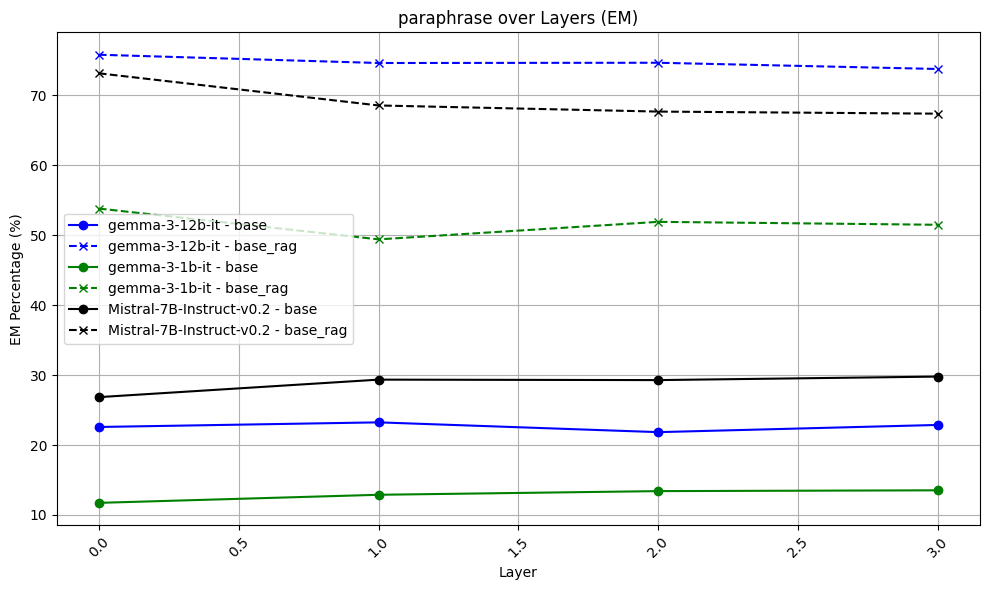


gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.258480   0.820116
     1    0.258959   0.803990
     2    0.250810   0.799551
     3    0.260530   0.790290

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0161
  Layer 2: Drop = -0.0044
  Layer 3: Drop = -0.0093

gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.135109   0.599454
     1    0.152284   0.548766
     2    0.155158   0.574430
     3    0.159399   0.570397

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0507
  Layer 2: Drop = 0.0257
  Layer 3: Drop = -0.0040

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.313878   0.794423
     1    0.333857   0.751922
     2    0.325470   0.735358
     3    0.347166   0.733179

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0425
  Layer 2: Drop = -0.0166
  Layer 3: Drop = -0.0022


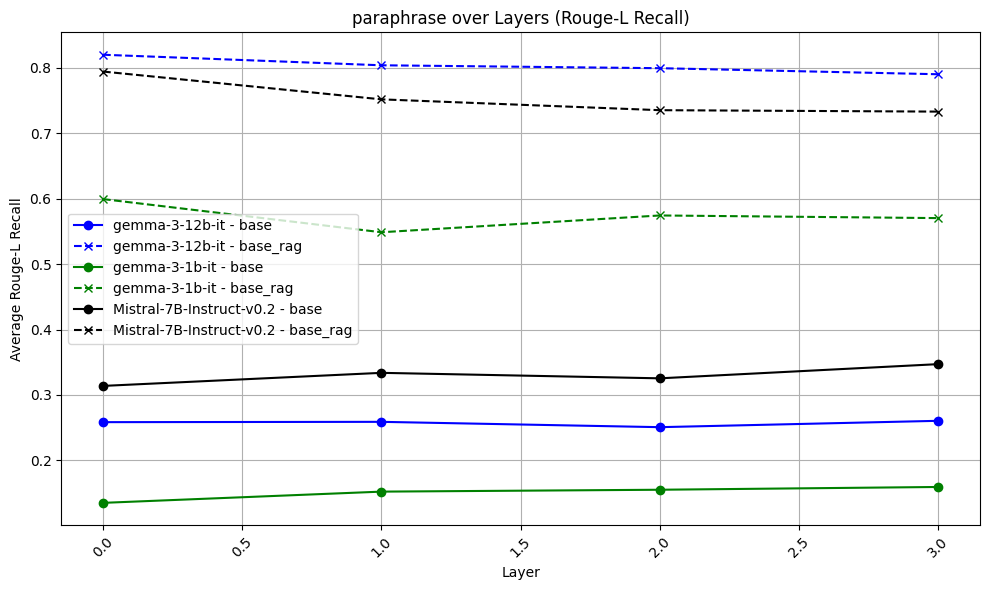


gemma-3-12b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.239029    0.605198
     1     0.220943    0.506442
     2     0.218032    0.537376
     3     0.229719    0.550453

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0988
  Layer 2: Drop = 0.0309
  Layer 3: Drop = 0.0131

gemma-3-1b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.106131    0.175688
     1     0.104192    0.142773
     2     0.106019    0.152264
     3     0.108967    0.159581

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0329
  Layer 2: Drop = 0.0095
  Layer 3: Drop = 0.0073

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.118898    0.396449
     1     0.102156    0.240581
     2     0.105927    0.292832
     3     0.116907    0.314802

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1559
  Layer 2: Drop = 0.0523
  Lay

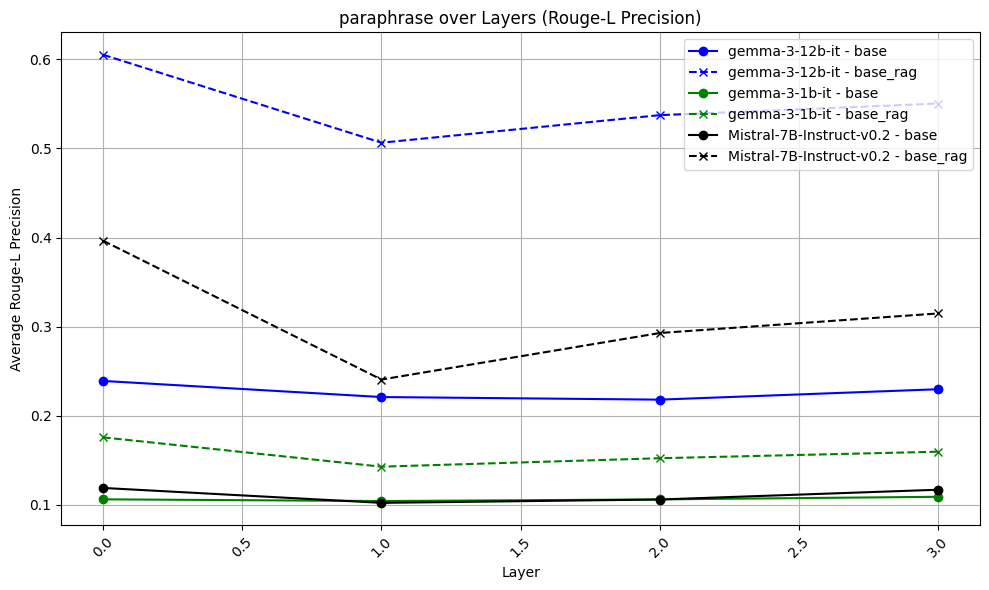


gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.239626  0.643492
     1   0.228593  0.557211
     2   0.224280  0.582527
     3   0.234090  0.591664

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0863
  Layer 2: Drop = 0.0253
  Layer 3: Drop = 0.0091

gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.109634  0.247405
     1   0.110580  0.199663
     2   0.112932  0.210328
     3   0.115901  0.215754

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0477
  Layer 2: Drop = 0.0107
  Layer 3: Drop = 0.0054

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.148027  0.458635
     1   0.135801  0.317608
     2   0.137979  0.357777
     3   0.147430  0.374918

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1410
  Layer 2: Drop = 0.0402
  Layer 3: Drop = 0.0171


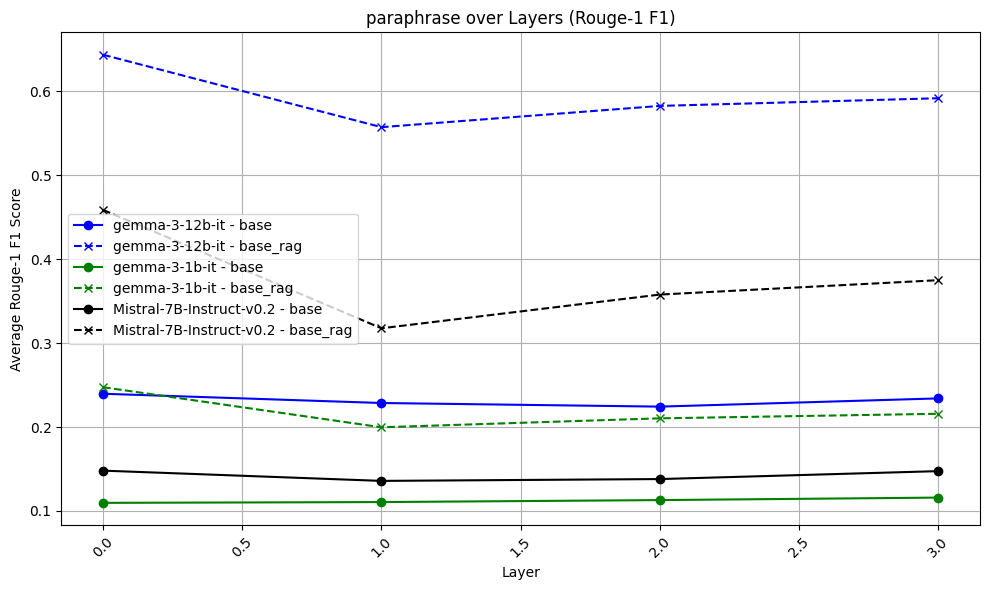


gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.239626  0.642381
     1   0.228143  0.555761
     2   0.223914  0.581288
     3   0.233844  0.590616

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0866
  Layer 2: Drop = 0.0255
  Layer 3: Drop = 0.0093

gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.109490  0.246081
     1   0.110332  0.198493
     2   0.112537  0.208428
     3   0.115298  0.214548

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0476
  Layer 2: Drop = 0.0099
  Layer 3: Drop = 0.0061

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.145602  0.455850
     1   0.134663  0.316044
     2   0.135749  0.355643
     3   0.145526  0.372821

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1398
  Layer 2: Drop = 0.0396
  Layer 3: Drop = 0.0172


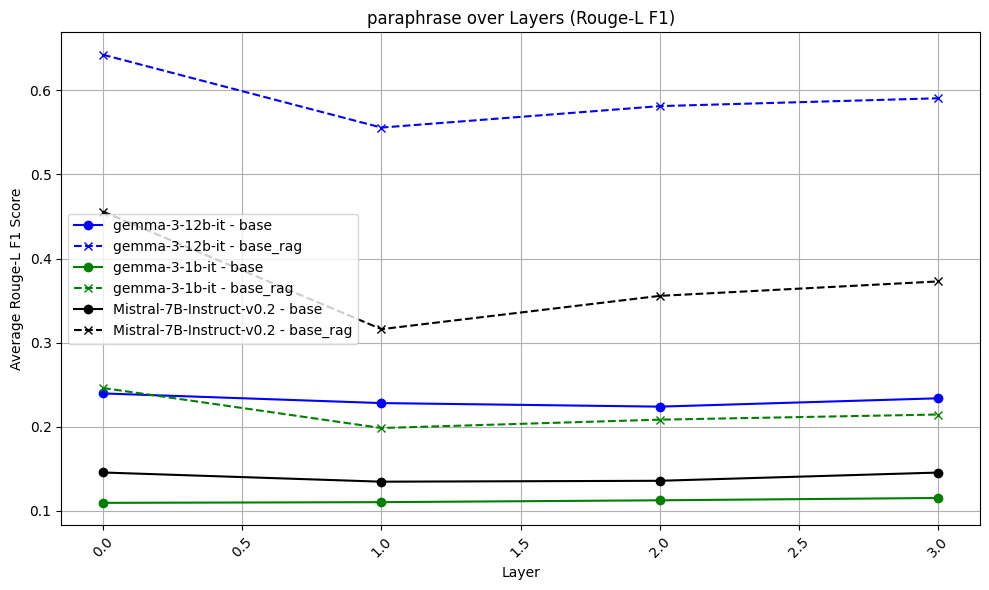

            
 _____ _____ _____ 
|_   _|     |  _  |
  | | |  |  |     |
  |_| |__  _|__|__|
         |__|      
    
/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 711
google/gemma-3-12b-it df len: 9017
/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 711
google/gemma-3-1b-it df len: 9017
/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 711
mistralai/Mistral-7B-Instruct-v0.2 df len: 9017

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 54.711674     56.540084
     1 50.309598     55.108359
     2 50.204415     53.270646
     3 49.168126     53.940455

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -1.4317
  Layer 2: Drop = -1.8377
  Layer 3: Drop = 0.6698

gemma-3-1b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 14.345992     

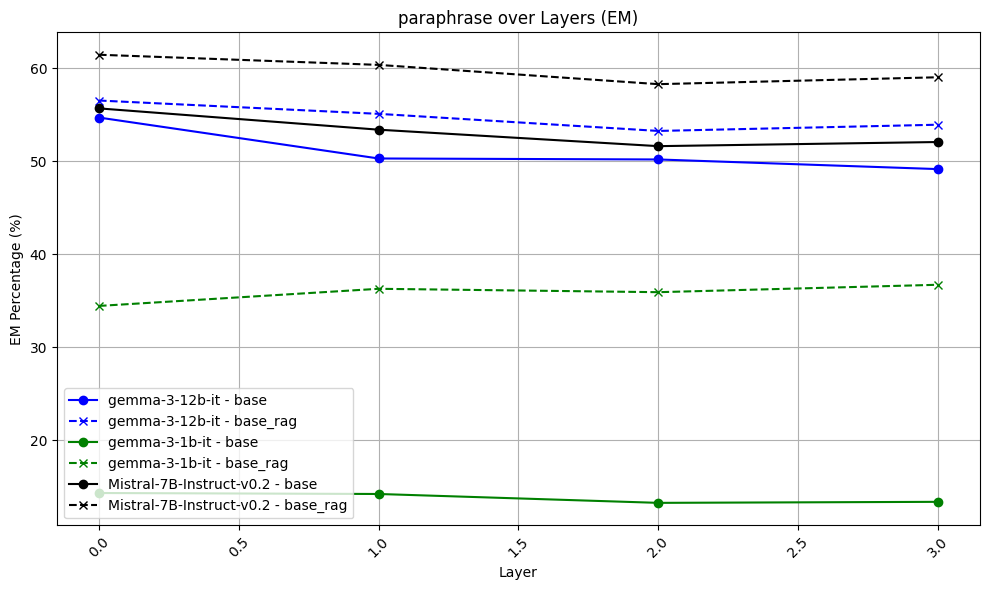


gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.618120   0.629700
     1    0.570820   0.620201
     2    0.571894   0.601792
     3    0.563628   0.606841

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0095
  Layer 2: Drop = -0.0184
  Layer 3: Drop = 0.0050

gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.189683   0.423843
     1    0.182688   0.434098
     2    0.177096   0.432227
     3    0.180088   0.436362

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0103
  Layer 2: Drop = -0.0019
  Layer 3: Drop = 0.0041

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.628247   0.683685
     1    0.607353   0.677374
     2    0.594208   0.655649
     3    0.598566   0.662373

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0063
  Layer 2: Drop = -0.0217
  Layer 3: Drop = 0.0067


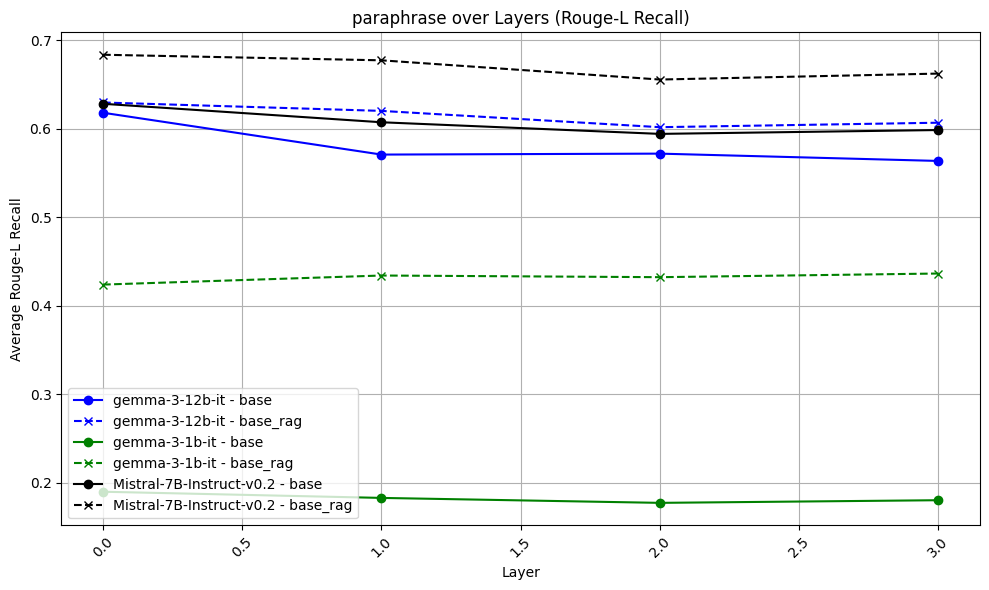


gemma-3-12b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.571310    0.458637
     1     0.497055    0.407097
     2     0.488171    0.381036
     3     0.482341    0.384269

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0515
  Layer 2: Drop = -0.0261
  Layer 3: Drop = 0.0032

gemma-3-1b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.128129    0.079065
     1     0.109240    0.076822
     2     0.105401    0.076898
     3     0.107046    0.072814

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0022
  Layer 2: Drop = 0.0001
  Layer 3: Drop = -0.0041

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.195382    0.238140
     1     0.172404    0.220182
     2     0.159408    0.210061
     3     0.168786    0.211743

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0180
  Layer 2: Drop = -0.0101
  

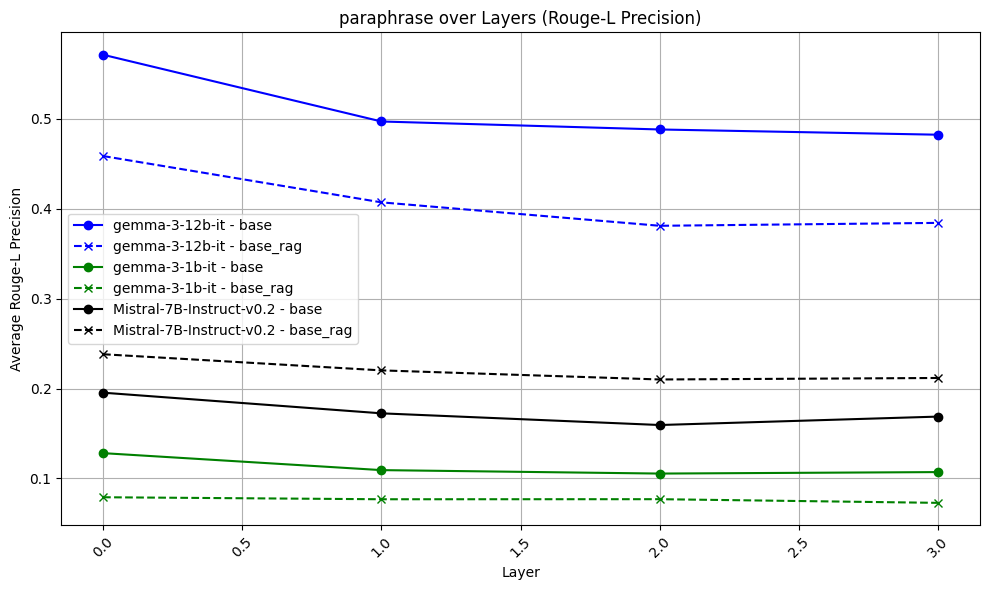


gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.581648  0.487817
     1   0.511754  0.439752
     2   0.504571  0.413151
     3   0.496783  0.417327

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0481
  Layer 2: Drop = -0.0266
  Layer 3: Drop = 0.0042

gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.138870  0.114286
     1   0.120360  0.110871
     2   0.115187  0.111388
     3   0.117240  0.107219

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0034
  Layer 2: Drop = 0.0005
  Layer 3: Drop = -0.0042

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.243389  0.279684
     1   0.215499  0.261302
     2   0.202469  0.250639
     3   0.210321  0.253344

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0184
  Layer 2: Drop = -0.0107
  Layer 3: Drop = 0.0027


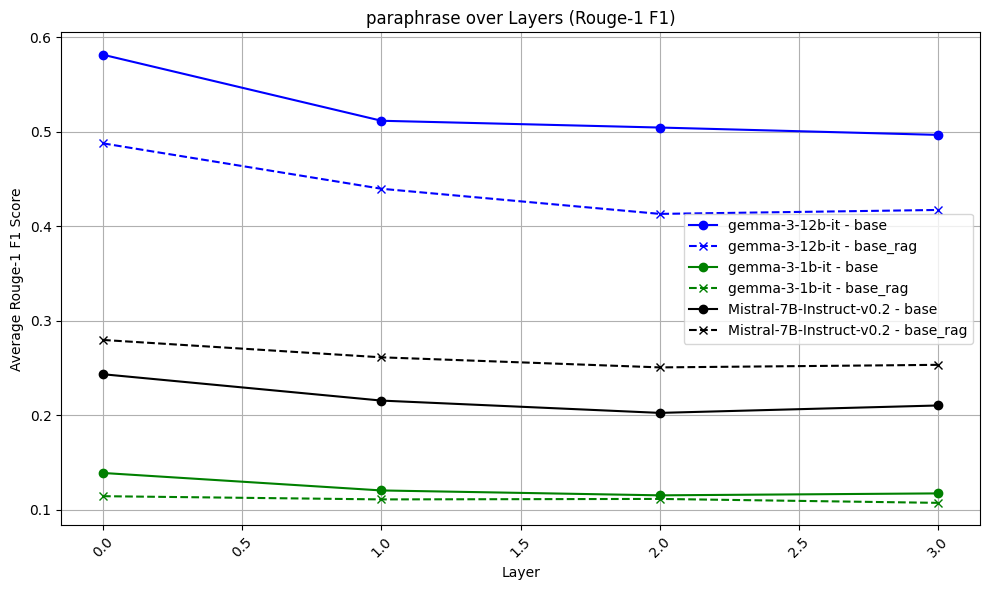


gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.579562  0.487354
     1   0.509825  0.438923
     2   0.502888  0.412378
     3   0.495553  0.416654

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0484
  Layer 2: Drop = -0.0265
  Layer 3: Drop = 0.0043

gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.138870  0.113550
     1   0.120099  0.110401
     2   0.114879  0.110848
     3   0.116996  0.106580

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0031
  Layer 2: Drop = 0.0004
  Layer 3: Drop = -0.0043

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.242581  0.278802
     1   0.214581  0.260747
     2   0.201468  0.249944
     3   0.209510  0.252619

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0181
  Layer 2: Drop = -0.0108
  Layer 3: Drop = 0.0027


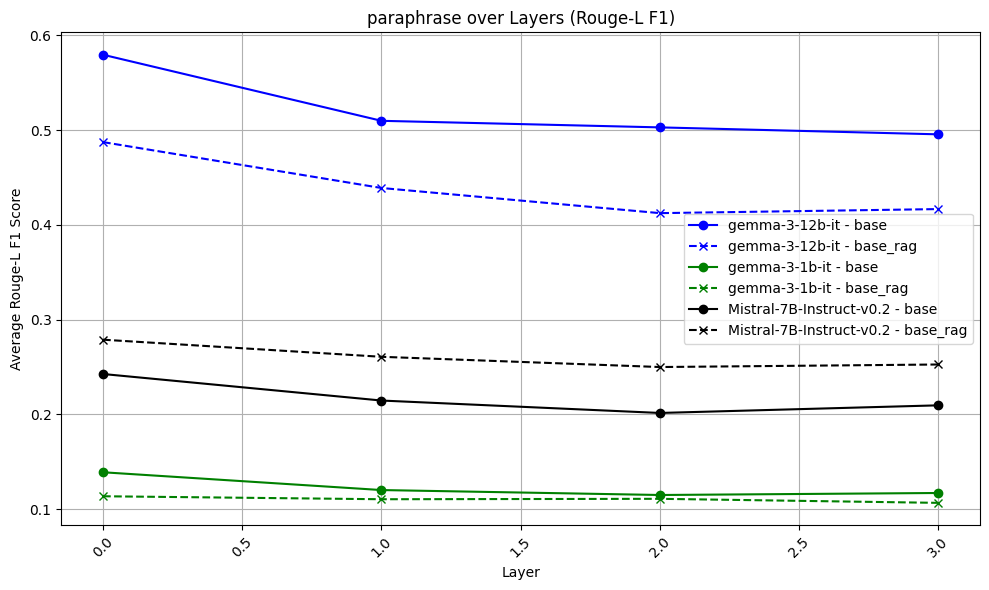

In [4]:
datasets = ["POPQA", "TQA"]
for dataset in datasets:
  print(constants.dataset_fancy_text[dataset])
  dfs_para_ = []
  for model in gen_models:
      try:
          df = read_trees_to_df("paraphrase", model, dataset)
          print(f"tree count: {df["question_id"].nunique()}")
          print(f"{model} df len: {len(df)}")
          dfs_para_.append(df)
      except KeyError as e:
          print(e)

  df_para_ = pd.concat(dfs_para_, ignore_index=True)
  # df_para_ = get_perplexity(df_para_)
  df_para_.to_csv(f"analysis/df_para_{dataset}_.csv")
  # perform groupby and aggregation
  df_grouped_para_ = agg_df(df_para_)
  df_grouped_para_.columns
  plot_by_layer(df_grouped_para_, gen_models, title="paraphrase")
  plot_by_layer(df_grouped_para_, gen_models, title="paraphrase", plot='recall_ROUGE_L')
  plot_by_layer(df_grouped_para_, gen_models, title="paraphrase", plot='prec_ROUGE_L')
  plot_by_layer(df_grouped_para_, gen_models, title="paraphrase", plot='f1_ROUGE_1')
  plot_by_layer(df_grouped_para_, gen_models, title="paraphrase", plot='f1_ROUGE_L')

In [178]:
df_filtered = df_para_.iloc[:140]  
with open("para_res", "w", encoding="utf-8") as f:
    for idx, row in df_filtered.iloc[:140].iterrows():
        f.write(f"{row['prompt']}\n")
        f.write(f"({row['rag_prec_L']}) ({row['layer']}) {row['para_type']}\n")
        f.write("closest match:\n" + str(list(c[0]['title'] for c in row['rag_closest_match'])))
        f.write(f"\n{row['possible_answers']}\n")
        f.write(f"{row['base_rag']}\n")
        f.write("=========================================\n")

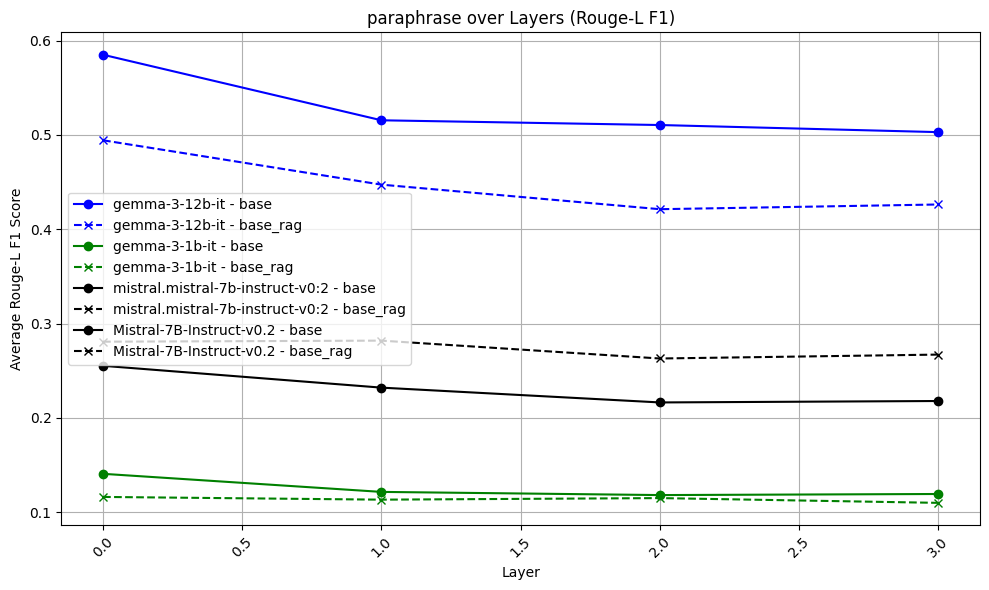

In [ ]:
plot_by_layer(df_grouped_para_, gen_models, title="paraphrase", plot='f1_ROUGE_L')

# para + dialect

/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 682
google/gemma-3-1b-it df len: 14986
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 682
google/gemma-3-12b-it df len: 8985
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 257
mistralai/Mistral-7B-Instruct-v0.2 df len: 4666

gemma-3-1b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 11.730205     53.812317
     1 12.885375     49.407115
     2 13.410119     51.912793
     3 13.524862     51.491713

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -4.4052
  Layer 2: Drop = 2.5057
  Layer 3: Drop = -0.4211

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 22.580645     75.806452
     1 23.241107     74.624506
     2 21.842863     74.660633
     3 22.872928     73.767956

RAG Drop

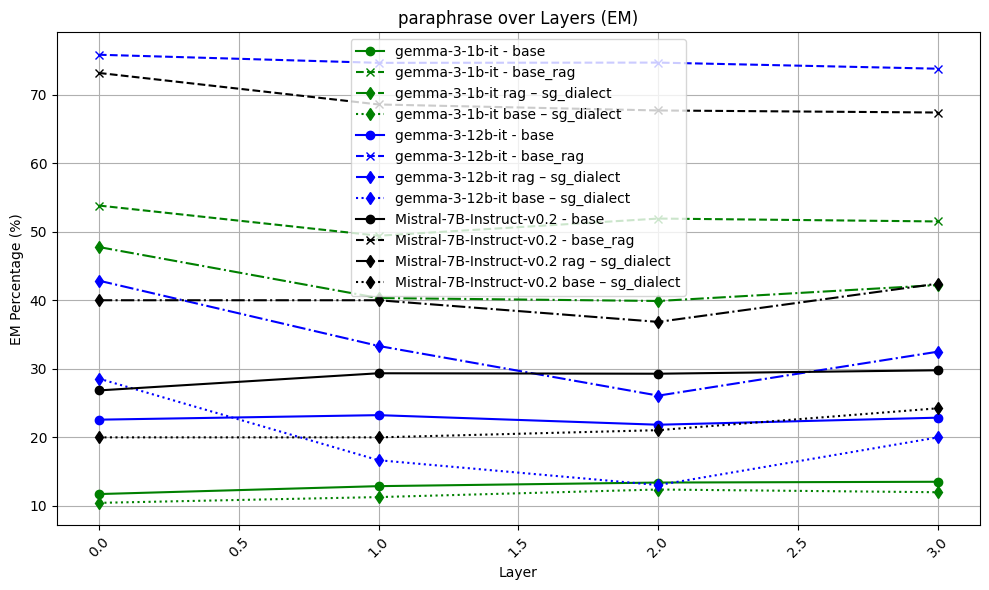


gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.135109   0.599454
     1    0.152284   0.548766
     2    0.155158   0.574430
     3    0.159399   0.570397

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0507
  Layer 2: Drop = 0.0257
  Layer 3: Drop = -0.0040

gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.258480   0.820116
     1    0.258959   0.803990
     2    0.250810   0.799551
     3    0.260530   0.790290

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0161
  Layer 2: Drop = -0.0044
  Layer 3: Drop = -0.0093

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.313878   0.794423
     1    0.333857   0.751922
     2    0.325470   0.735358
     3    0.347166   0.733179

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0425
  Layer 2: Drop = -0.0166
  Layer 3: Drop = -0.0022


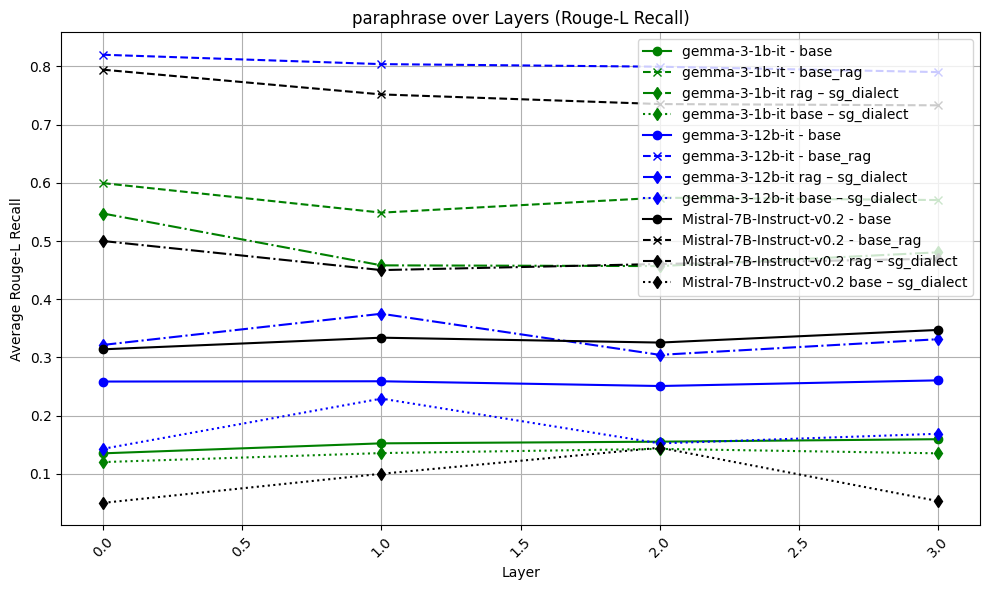


gemma-3-1b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.106131    0.175688
     1     0.104192    0.142773
     2     0.106019    0.152264
     3     0.108967    0.159581

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0329
  Layer 2: Drop = 0.0095
  Layer 3: Drop = 0.0073

gemma-3-12b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.239029    0.605198
     1     0.220943    0.506442
     2     0.218032    0.537376
     3     0.229719    0.550453

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0988
  Layer 2: Drop = 0.0309
  Layer 3: Drop = 0.0131

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.118898    0.396449
     1     0.102156    0.240581
     2     0.105927    0.292832
     3     0.116907    0.314802

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1559
  Layer 2: Drop = 0.0523
  Lay

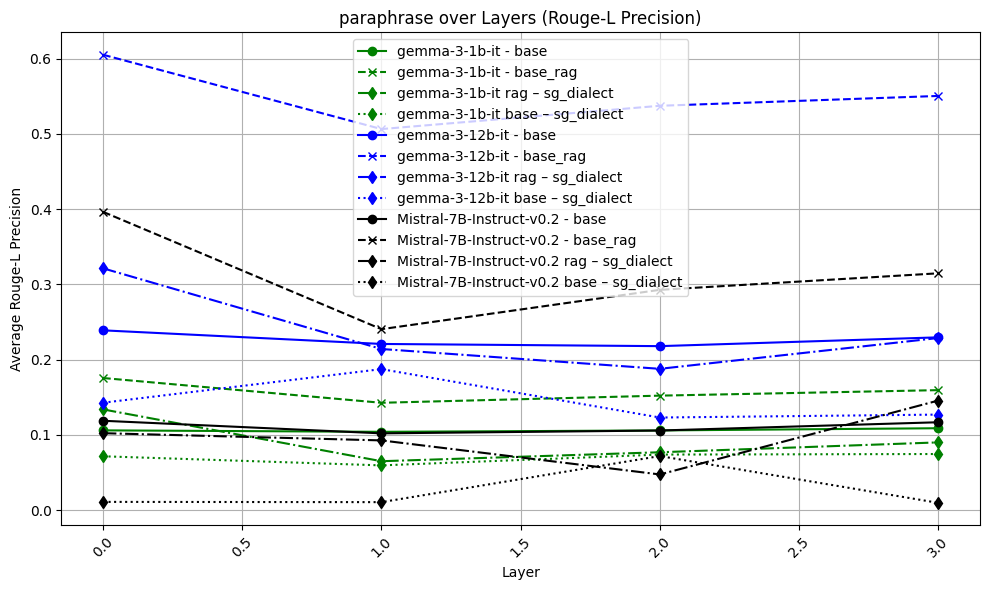


gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.109634  0.247405
     1   0.110580  0.199663
     2   0.112932  0.210328
     3   0.115901  0.215754

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0477
  Layer 2: Drop = 0.0107
  Layer 3: Drop = 0.0054

gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.239626  0.643492
     1   0.228593  0.557211
     2   0.224280  0.582527
     3   0.234090  0.591664

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0863
  Layer 2: Drop = 0.0253
  Layer 3: Drop = 0.0091

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.148027  0.458635
     1   0.135801  0.317608
     2   0.137979  0.357777
     3   0.147430  0.374918

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1410
  Layer 2: Drop = 0.0402
  Layer 3: Drop = 0.0171


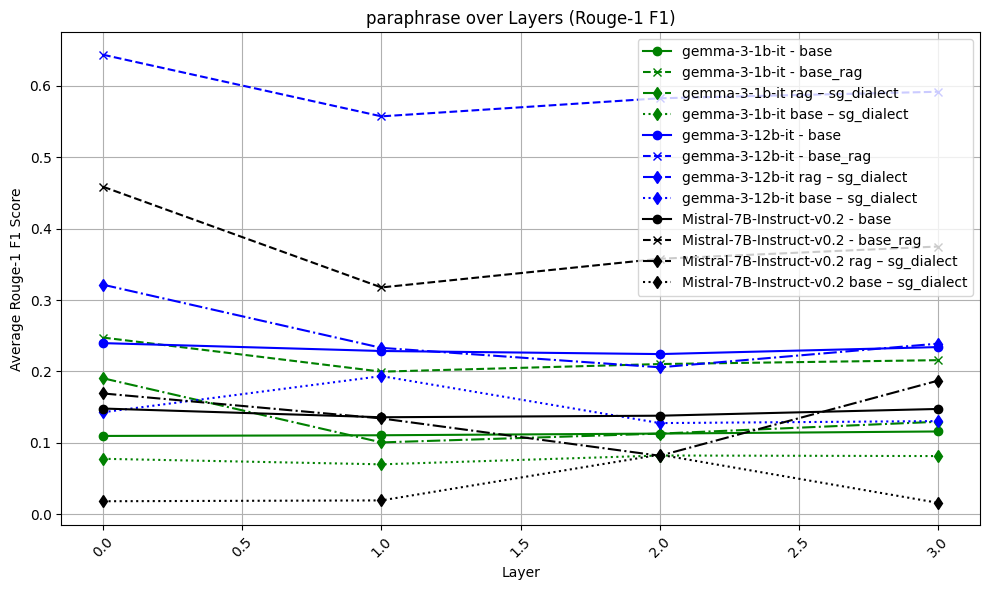


gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.109490  0.246081
     1   0.110332  0.198493
     2   0.112537  0.208428
     3   0.115298  0.214548

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0476
  Layer 2: Drop = 0.0099
  Layer 3: Drop = 0.0061

gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.239626  0.642381
     1   0.228143  0.555761
     2   0.223914  0.581288
     3   0.233844  0.590616

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0866
  Layer 2: Drop = 0.0255
  Layer 3: Drop = 0.0093

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.145602  0.455850
     1   0.134663  0.316044
     2   0.135749  0.355643
     3   0.145526  0.372821

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1398
  Layer 2: Drop = 0.0396
  Layer 3: Drop = 0.0172


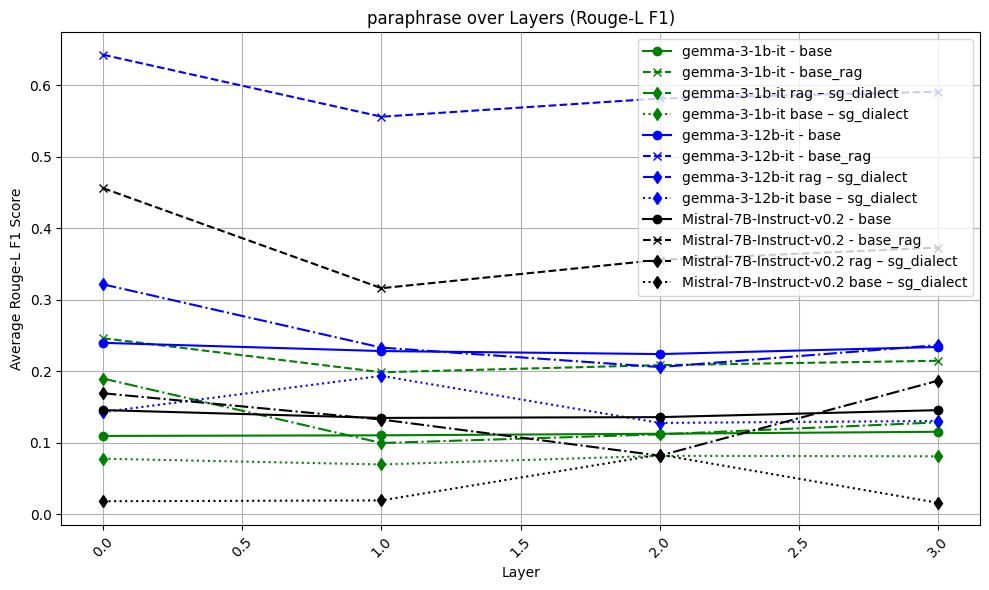

/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 711
google/gemma-3-1b-it df len: 17772
/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 711
google/gemma-3-12b-it df len: 11314
/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 711
mistralai/Mistral-7B-Instruct-v0.2 df len: 9017

gemma-3-1b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 13.065327     43.933955
     1 13.570591     42.784513
     2 13.348370     43.899938
     3 13.460904     44.077862

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -1.1494
  Layer 2: Drop = 1.1154
  Layer 3: Drop = 0.1779

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 38.980617     65.972721
     1 36.918264     64.763395
     2 36.067254     63.932746
     3 36.082701     63.807324

RAG Drop per l

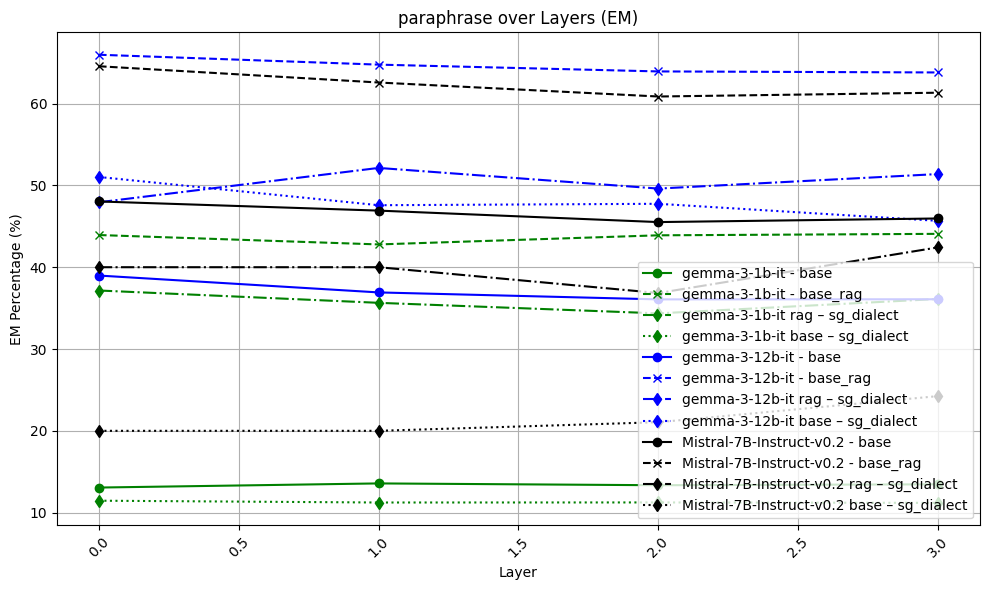


gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.162964   0.509821
     1    0.167647   0.490827
     2    0.166161   0.503110
     3    0.169792   0.503062

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0190
  Layer 2: Drop = 0.0123
  Layer 3: Drop = -0.0000

gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.442044   0.722926
     1    0.416536   0.711125
     2    0.411846   0.700367
     3    0.412795   0.698132

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0118
  Layer 2: Drop = -0.0108
  Layer 3: Drop = -0.0022

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.544783   0.713085
     1    0.533607   0.697475
     2    0.520640   0.677469
     3    0.529538   0.681815

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0156
  Layer 2: Drop = -0.0200
  Layer 3: Drop = 0.0043


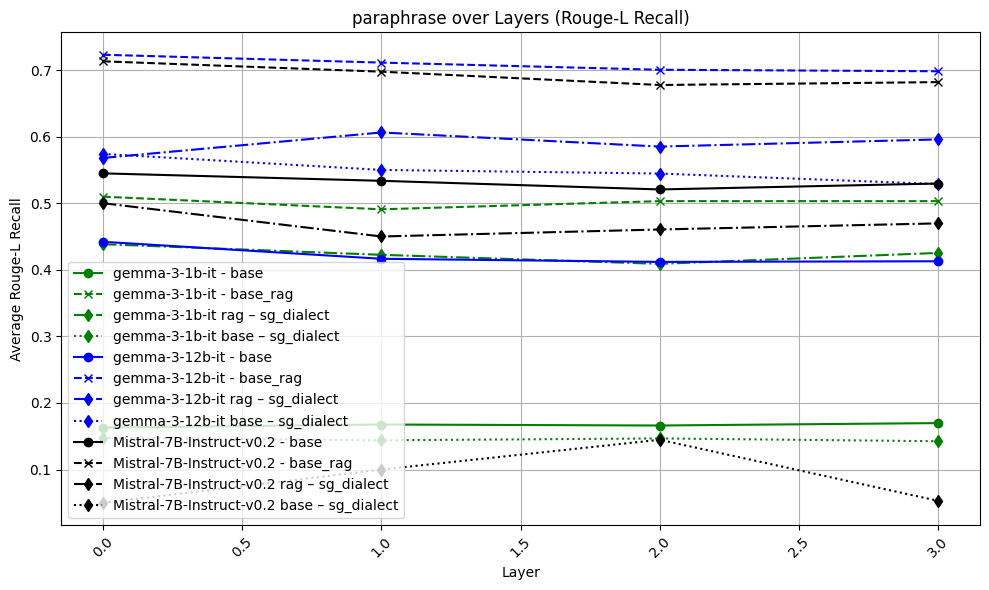


gemma-3-1b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.117359    0.126371
     1     0.106743    0.109449
     2     0.105709    0.114465
     3     0.108002    0.115992

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0169
  Layer 2: Drop = 0.0050
  Layer 3: Drop = 0.0015

gemma-3-12b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.408628    0.530392
     1     0.360457    0.456245
     2     0.353517    0.458966
     3     0.356627    0.466968

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0741
  Layer 2: Drop = 0.0027
  Layer 3: Drop = 0.0080

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.175076    0.280171
     1     0.153462    0.225682
     2     0.144767    0.232720
     3     0.154541    0.240040

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0545
  Layer 2: Drop = 0.0070
  Lay

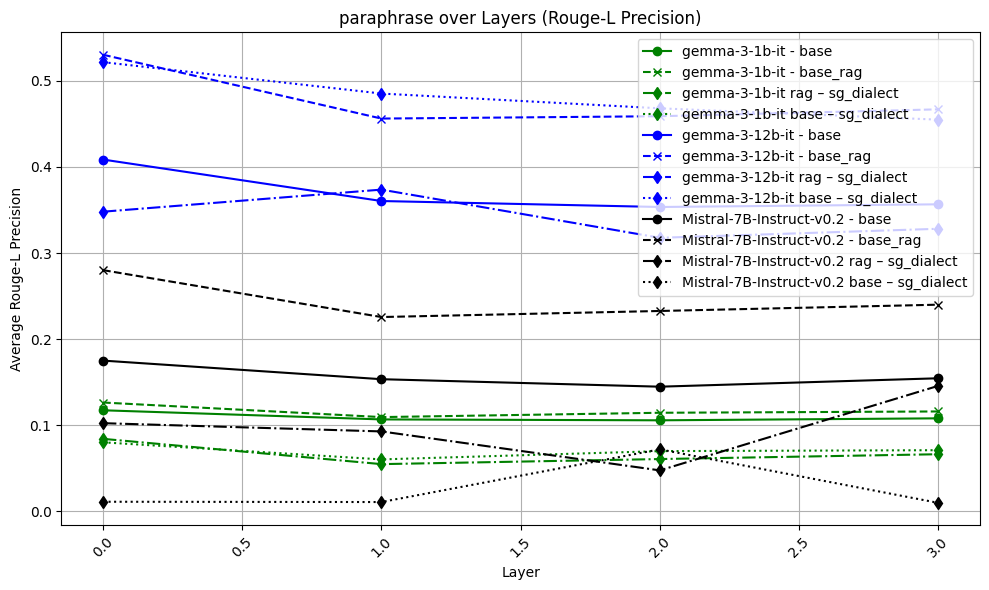


gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.124556  0.179460
     1   0.115522  0.154798
     2   0.114063  0.160706
     3   0.116574  0.161230

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0247
  Layer 2: Drop = 0.0059
  Layer 3: Drop = 0.0005

gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.414197  0.564034
     1   0.371668  0.497861
     2   0.364857  0.497578
     3   0.366058  0.504083

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0662
  Layer 2: Drop = -0.0003
  Layer 3: Drop = 0.0065

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.218071  0.327195
     1   0.194009  0.276485
     2   0.184815  0.279969
     3   0.193053  0.286725

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0507
  Layer 2: Drop = 0.0035
  Layer 3: Drop = 0.0068


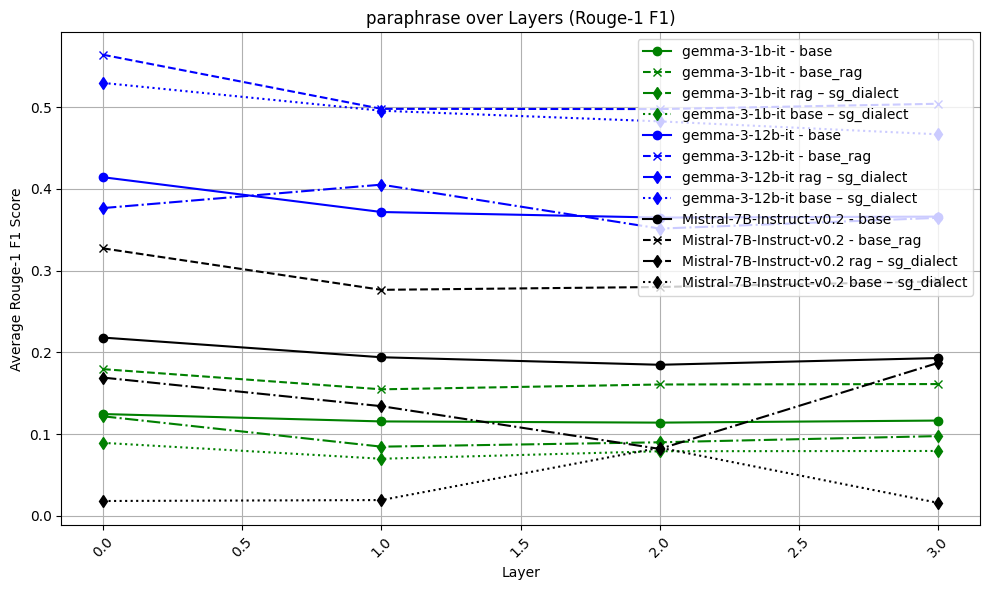


gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.124486  0.178436
     1   0.115267  0.153982
     2   0.113712  0.159488
     3   0.116151  0.160309

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0245
  Layer 2: Drop = 0.0055
  Layer 3: Drop = 0.0008

gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.413132  0.563254
     1   0.370471  0.496725
     2   0.363830  0.496573
     3   0.365317  0.503223

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0665
  Layer 2: Drop = -0.0002
  Layer 3: Drop = 0.0066

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.216833  0.325808
     1   0.193031  0.275657
     2   0.183477  0.278880
     3   0.191942  0.285623

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0502
  Layer 2: Drop = 0.0032
  Layer 3: Drop = 0.0067


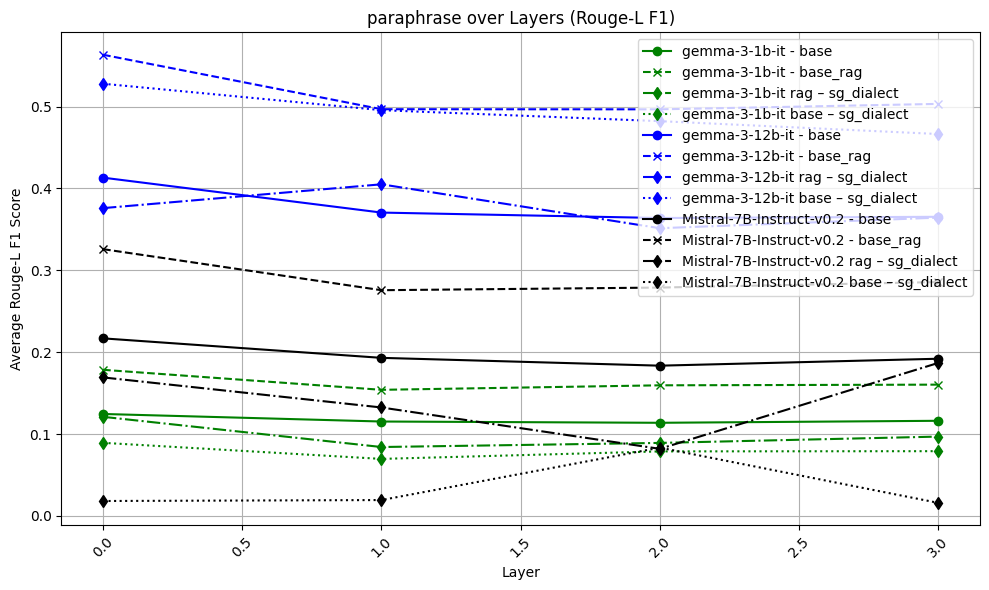

In [5]:
dfs_para_ = []
datasets = ["POPQA", "TQA"]
gen_models = constants.MODELS
for dataset in datasets:
    for model in gen_models:
        try:
            df = read_trees_to_df("paraphrase", model, dataset, terminal=True)
            print(f"tree count: {df["question_id"].nunique()}")
            print(f"{model} df len: {len(df)}")
            dfs_para_.append(df)
        except KeyError as e:
            print(e)

    combined_dialect_df = pd.concat(dfs_para_, ignore_index=True)
    combined_dialect_df.to_csv(f"analysis/{dataset}-paraphrase-trees.csv")
    df_grouped_dialect_para_ = agg_df(combined_dialect_df)

    plot_by_layer(df_grouped_dialect_para_, gen_models, title="paraphrase", terminal_comparison=['sg_dialect'])
    plot_by_layer(df_grouped_dialect_para_, gen_models, title="paraphrase", plot='recall_ROUGE_L', terminal_comparison=['sg_dialect'])
    plot_by_layer(df_grouped_dialect_para_, gen_models, title="paraphrase", plot='prec_ROUGE_L', terminal_comparison=['sg_dialect'])
    plot_by_layer(df_grouped_dialect_para_, gen_models, title="paraphrase", plot='f1_ROUGE_1', terminal_comparison=['sg_dialect'])
    plot_by_layer(df_grouped_dialect_para_, gen_models, title="paraphrase", plot='f1_ROUGE_L', terminal_comparison=['sg_dialect'])


In [8]:
from functools import reduce
import pandas as pd

# 1) Build a mapping model → set of tree_index for POPQA
tree_index_sets = {}
for model in constants.MODELS:
    try:
        df = read_trees_to_df("paraphrase", model, "POPQA", terminal=True)
        # if your tree‐index is in a column use ['tree_index'], 
        # otherwise you can use df.index
        tree_index_sets[model] = set(df["tree_index"])
    except KeyError:
        # model didn’t produce any POPQA trees
        tree_index_sets[model] = set()
        print(f"No POPQA trees for {model!r}")

# 2) Pull out Mistral’s set
mistral_idx = tree_index_sets.get("mistral", set())
print(f"Mistral produced {len(mistral_idx)} POPQA trees.")

# 3a) If you just want all the indices where Mistral has a tree:
print("→ Tree-indices where Mistral exists:", sorted(mistral_idx))

# 3b) If you want, for each other model, the intersection with Mistral:
for m, idx_set in tree_index_sets.items():
    if m == "mistral":
        continue
    inter = mistral_idx & idx_set
    print(f"  • {m!r} ∩ mistral: {len(inter)} common trees")

# 3c) If you want the indices common to *every* model (i.e. across all models, including Mistral):
#     (only models with at least one tree)
non_empty_sets = [s for s in tree_index_sets.values() if s]
common_all = set.intersection(*non_empty_sets) if non_empty_sets else set()
print(f"Trees common to all models: {len(common_all)} →", sorted(common_all))


/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
No POPQA trees for 'google/gemma-3-1b-it'
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
No POPQA trees for 'google/gemma-3-12b-it'
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
No POPQA trees for 'mistralai/Mistral-7B-Instruct-v0.2'
Mistral produced 0 POPQA trees.
→ Tree-indices where Mistral exists: []
  • 'google/gemma-3-1b-it' ∩ mistral: 0 common trees
  • 'google/gemma-3-12b-it' ∩ mistral: 0 common trees
  • 'mistralai/Mistral-7B-Instruct-v0.2' ∩ mistral: 0 common trees
Trees common to all models: 0 → []


In [3]:
# read a tree
from collections import deque
from tree.tree import ReadTree
path = '/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/225_checked.pkl'
rt = ReadTree.load_read_tree(path)
root = rt.root
nqueue = deque([root])
while nqueue:
    print('==============')
    node = nqueue.pop()
    print(node.answers)
    print(node.metadata)
    nqueue.extend(node.children)
    

{'mistralai/Mistral-7B-Instruct-v0.2': {'base': 'Golda Meir was the Israeli Prime Minister from 1969 to 1974.', 'base_rag': 'Golda Meir'}}
{'terminal_applied': ['question_position_suffix', 'question_position_middle', 'sg_dialect']}
{'mistralai/Mistral-7B-Instruct-v0.2': {'base': 'Golda Meir was the Israeli Prime Minister from 1969 to 1974.', 'base_rag': 'Golda Meir was the Israeli Prime Minister from 1969 to 1974.'}}
{'terminal_applied': ['question_position_suffix', 'question_position_middle', 'sg_dialect'], 'terminal_name': 'question_position_middle;sg_dialect', 'terminal_prompt': 'One had been Israeli Prime Minister 1969 1974?', 'is_valid': True, 'position': 'middle', 'num_extra_sent': 0, 'level': 0, 'rules': {(31, 35): {'value': '', 'type': 'null_prepositions', 'token_alignment': {}}, (41, 43): {'value': '', 'type': 'null_prepositions', 'token_alignment': {}}, (0, 2): {'value': 'One', 'type': 'one_relativizer', 'token_alignment': {}}, (4, 6): {'value': 'had been', 'type': 'present_p

# paraprefix

/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 555
google/gemma-3-1b-it df len: 11922
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 555
google/gemma-3-12b-it df len: 11410
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 376
mistralai/Mistral-7B-Instruct-v0.2 df len: 7829

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 54.054054     58.198198
     1 48.118812     56.138614
     2 49.584631     54.465213
     3 48.877805     54.308673

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -2.0596
  Layer 2: Drop = -1.6734
  Layer 3: Drop = -0.1565

gemma-3-1b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 14.054054     36.396396
     1 10.495050     34.158416
     2 11.163032     34.267913
     3 10.196730     3

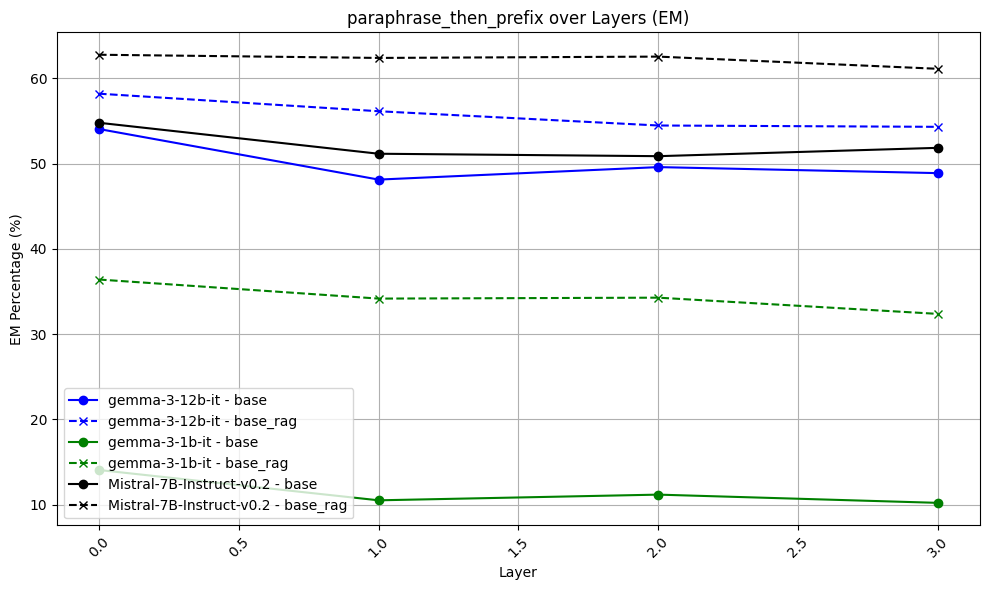


gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.604753   0.639438
     1    0.545983   0.619008
     2    0.560584   0.603884
     3    0.549208   0.600976

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0204
  Layer 2: Drop = -0.0151
  Layer 3: Drop = -0.0029

gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.188825   0.434264
     1    0.150215   0.403039
     2    0.151351   0.405668
     3    0.145556   0.387924

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0312
  Layer 2: Drop = 0.0026
  Layer 3: Drop = -0.0177

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.619681   0.681244
     1    0.569154   0.686476
     2    0.571305   0.683809
     3    0.578852   0.669139

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0052
  Layer 2: Drop = -0.0027
  Layer 3: Drop = -0.0147


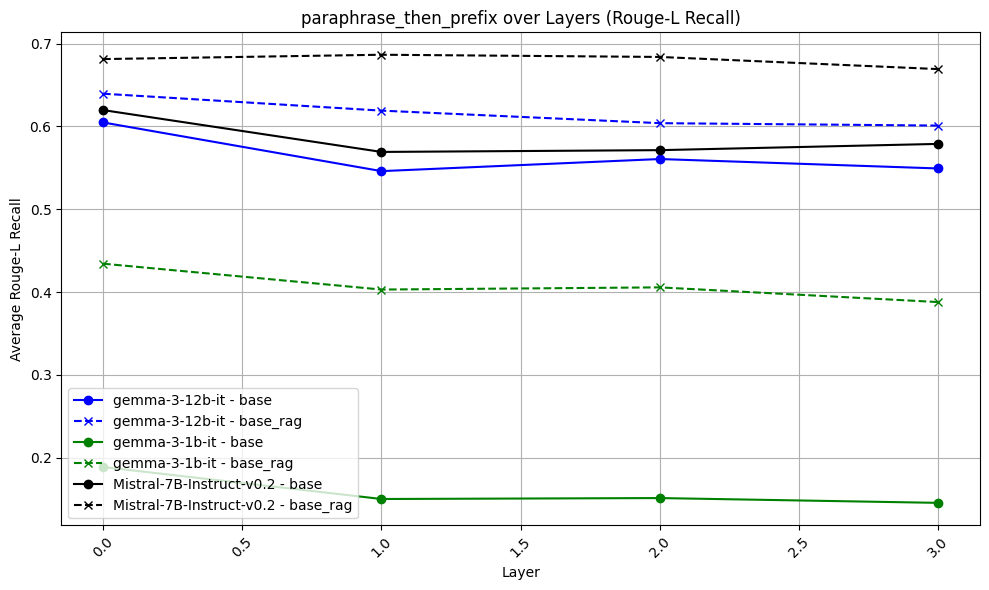


gemma-3-12b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.568426    0.468533
     1     0.483606    0.458418
     2     0.495243    0.439002
     3     0.487676    0.445931

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0101
  Layer 2: Drop = -0.0194
  Layer 3: Drop = 0.0069

gemma-3-1b-it Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.126196    0.086033
     1     0.075269    0.044718
     2     0.072214    0.036048
     3     0.066813    0.029842

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0413
  Layer 2: Drop = -0.0087
  Layer 3: Drop = -0.0062

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_prec_L  rag_prec_L
     0     0.195453    0.227638
     1     0.165501    0.250534
     2     0.149525    0.246952
     3     0.172860    0.246088

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0229
  Layer 2: Drop = -0.0036
  

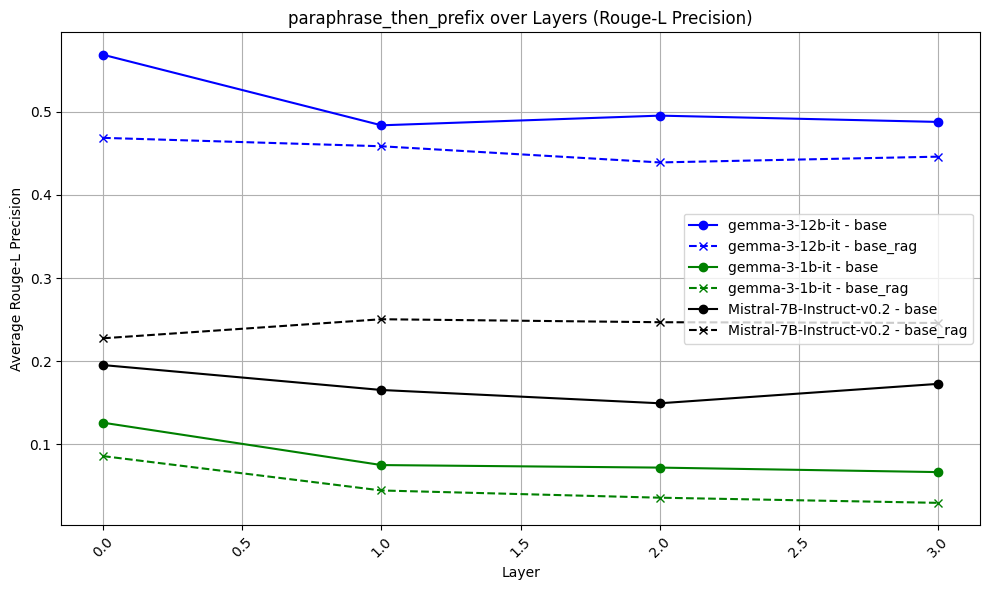


gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.575841  0.498446
     1   0.494423  0.483376
     2   0.505485  0.464770
     3   0.496720  0.471426

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0151
  Layer 2: Drop = -0.0186
  Layer 3: Drop = 0.0067

gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.137520  0.123750
     1   0.086027  0.073174
     2   0.081841  0.061401
     3   0.077533  0.050689

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0506
  Layer 2: Drop = -0.0118
  Layer 3: Drop = -0.0107

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.242065  0.271253
     1   0.205767  0.294018
     2   0.189769  0.288606
     3   0.211769  0.288314

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0228
  Layer 2: Drop = -0.0054
  Layer 3: Drop = -0.0003


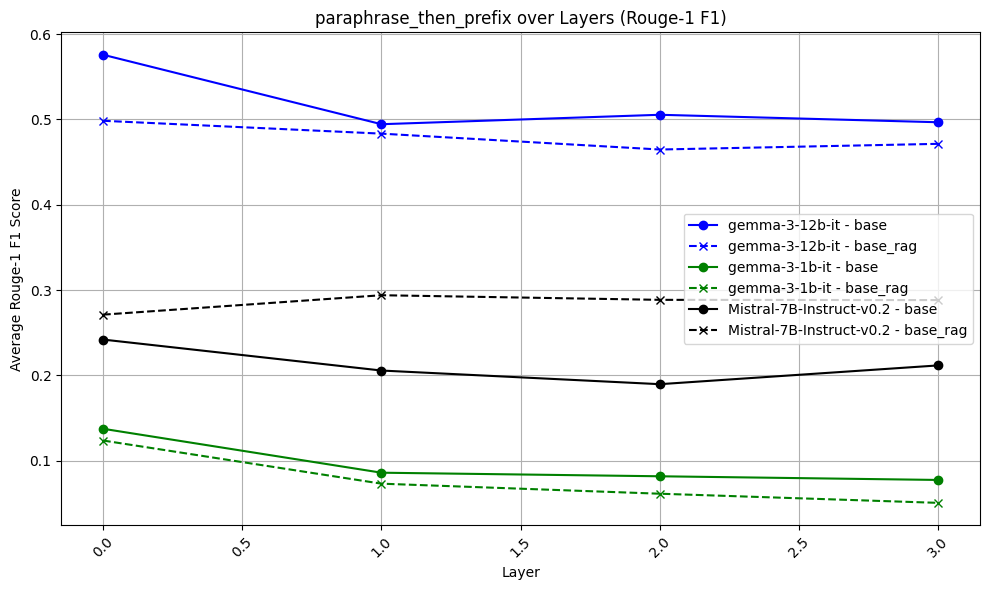


gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.573889  0.498005
     1   0.492135  0.482261
     2   0.504139  0.464099
     3   0.495564  0.470822

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0157
  Layer 2: Drop = -0.0182
  Layer 3: Drop = 0.0067

gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.137520  0.122979
     1   0.086027  0.072771
     2   0.081661  0.060675
     3   0.077157  0.050149

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0502
  Layer 2: Drop = -0.0121
  Layer 3: Drop = -0.0105

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.241702  0.270330
     1   0.205066  0.293560
     2   0.188741  0.287941
     3   0.210824  0.287578

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0232
  Layer 2: Drop = -0.0056
  Layer 3: Drop = -0.0004


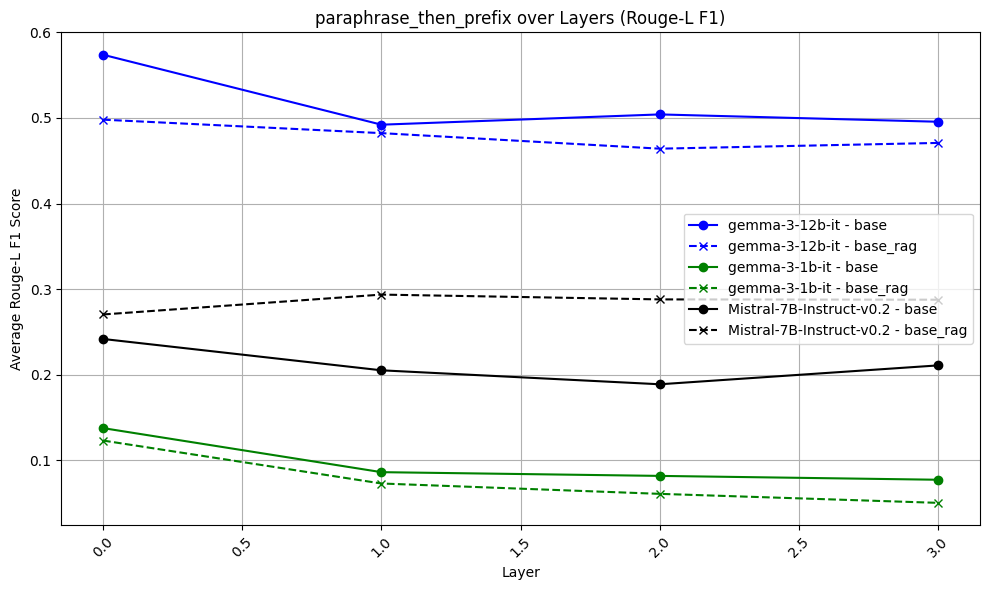

In [8]:
import utils.constants as constants
dfs_positions_ = []
dataset = "TQA"
for model in constants.MODELS:
    try:
        df = read_trees_to_df("paraphrase_then_prefix", model, dataset, terminal=True)
        print(f"tree count: {df["question_id"].nunique()}")
        print(f"{model} df len: {len(df)}")
        dfs_positions_.append(df)
    except KeyError as e:
        print(e)

combined_position_df = pd.concat(dfs_positions_, ignore_index=True)
df_grouped_paraprefix_position_ = agg_df(combined_position_df)

plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", terminal_comparison=['question_position_suffix, question_position_middle'])
plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", plot='recall_ROUGE_L', terminal_comparison=['question_position_suffix, question_position_middle'])
plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", plot='prec_ROUGE_L', terminal_comparison=['question_position_suffix, question_position_middle'])
plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", plot='f1_ROUGE_1', terminal_comparison=['question_position_suffix, question_position_middle'])
plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", plot='f1_ROUGE_L', terminal_comparison=['question_position_suffix, question_position_middle'])

In [1]:
import utils.constants as constants
dfs_positions_ = []
datasets = ["TQA", "POPQA"]
for dataset in datasets:
    for model in constants.MODELS:
        try:
            df = read_trees_to_df("paraphrase_then_prefix", model, dataset, terminal=True)
            print(f"tree count: {df["question_id"].nunique()}")
            print(f"{model} df len: {len(df)}")
            dfs_positions_.append(df)
        except KeyError as e:
            print(e)

combined_position_df = pd.concat(dfs_positions_, ignore_index=True)
combined_position_df.to_csv(f'/homes/lst20/fyp/fyp_resources/LexEval-main/analysis/{dataset}-paraphrase_then_prefix-trees.csv')
df_grouped_paraprefix_position_ = agg_df(combined_position_df)

plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", terminal_comparison=['question_position_suffix, question_position_middle'])
plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", plot='recall_ROUGE_L', terminal_comparison=['question_position_suffix, question_position_middle'])
plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", plot='prec_ROUGE_L', terminal_comparison=['question_position_suffix, question_position_middle'])
plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", plot='f1_ROUGE_1', terminal_comparison=['question_position_suffix, question_position_middle'])
plot_by_layer(df_grouped_paraprefix_position_, gen_models, title="paraphrase_then_prefix", plot='f1_ROUGE_L', terminal_comparison=['question_position_suffix, question_position_middle'])

NameError: name 'read_trees_to_df' is not defined

# long trees

In [57]:
df_grouped_paraprefix_position_[['layer', 'base_rag_true', 'base_rag_false', 'base_false', 'base_true', 'gen_modelId', 'para_type']]

,layer,base_rag_true,base_rag_false,base_false,base_true,gen_modelId,para_type
0,0,2,0,1,1,google/gemma-3-12b-it,question_position_middle
1,1,4,0,2,2,google/gemma-3-12b-it,question_position_middle
2,2,7,0,4,3,google/gemma-3-12b-it,question_position_middle
3,3,14,0,8,6,google/gemma-3-12b-it,question_position_middle
4,0,2,0,1,1,google/gemma-3-12b-it,question_position_suffix
5,1,4,0,2,2,google/gemma-3-12b-it,question_position_suffix
6,2,7,0,4,3,google/gemma-3-12b-it,question_position_suffix
7,3,14,0,8,6,google/gemma-3-12b-it,question_position_suffix
8,0,323,232,255,300,google/gemma-3-12b-it,semantic
9,1,567,443,524,486,google/gemma-3-12b-it,semantic


In [35]:
print(df_grouped_dialect_para_.columns)
df_grouped_dialect_para_[['layer', 'base_rag_true', 'base_rag_false', 'base_false', 'base_true', 'gen_modelId', 'para_type']]

Index(['gen_modelId', 'para_type', 'layer', 'base_true', 'base_false',
       'base_pct', 'base_rag_true', 'base_rag_false', 'base_rag_pct',
       'base_f1_1', 'rag_f1_1', 'base_f1_L', 'rag_f1_L', 'base_rec_1',
       'rag_rec_1', 'base_rec_L', 'rag_rec_L', 'base_prec_1', 'rag_prec_1',
       'base_prec_L', 'rag_prec_L'],
      dtype='object')


,layer,base_rag_true,base_rag_false,base_false,base_true,gen_modelId,para_type
0,0,517,165,528,154,google/gemma-3-12b-it,semantic
1,1,944,321,971,294,google/gemma-3-12b-it,semantic
2,2,1815,616,1900,531,google/gemma-3-12b-it,semantic
3,3,3338,1187,3490,1035,google/gemma-3-12b-it,semantic
4,0,3,4,5,2,google/gemma-3-12b-it,sg_dialect
5,1,4,8,10,2,google/gemma-3-12b-it,sg_dialect
6,2,6,17,20,3,google/gemma-3-12b-it,sg_dialect
7,3,13,27,32,8,google/gemma-3-12b-it,sg_dialect
8,0,367,315,602,80,google/gemma-3-1b-it,semantic
9,1,625,640,1102,163,google/gemma-3-1b-it,semantic


In [188]:
import pandas as pd

# 1. IDs answered correctly in the semantic setting
semantic_correct_qids = set(
    combined_dialect_df.loc[
        (combined_dialect_df['para_type'] == 'semantic')
      & (combined_dialect_df['rag_prec_L'] > 0)
      & (combined_dialect_df['rag_rec_L'] == 1),
        'question_id'
    ]
)

# 2. IDs that failed in the hk_dialect setting
hk_failed_qids = set(
    combined_dialect_df.loc[
        (combined_dialect_df['para_type'] == 'hk_dialect')
      & (combined_dialect_df['rag_rec_L'] == 0),
        'question_id'
    ]
)

# 3. Intersection: those where semantic succeeded but hk_dialect failed
target_qids = semantic_correct_qids & hk_failed_qids

print(f"Found {len(target_qids)} question_ids where semantic succeeded but hk_dialect failed.")

# 4. Now filter to only the hk_dialect rows for those question_ids
hk_only = combined_dialect_df[
    (combined_dialect_df['para_type'] == 'hk_dialect') &
    (combined_dialect_df['question_id'].isin(target_qids))
].reset_index(drop=True)

# If you only want the first N rows overall, e.g. 140:
hk_only_subset = hk_only.iloc[:900]

# 5. Dump to file
with open("hk_dialect_failures.txt", "w", encoding="utf-8") as f:
    for _, row in hk_only_subset.iterrows():
        f.write(f"{row['prompt']}\n")
        f.write(f"Precision: {row['rag_prec_L']} | Layer: {row['layer']} | para_type: {row['para_type']}\n")
    
        f.write(f"Possible answers: {row['possible_answers']}\n")
        f.write(f"Base RAG output: {row['base_rag']}\n")
        f.write("―" * 40 + "\n")


Found 75 question_ids where semantic succeeded but hk_dialect failed.


In [6]:
dialect_dfs = []
datasets = ["POPQA"]
for dataset in datasets:
    print(constants.dataset_fancy_text[dataset])
    for model in gen_models:
        try:
            df = pd.read_csv("/homes/lst20/fyp/fyp_resources/tree_backups/long_prefix_COPY_DONOT_DELETE.csv")
            print(df.columns)
            print(f"tree count: {df["question_id"].nunique()}")
            print(f"{model} df len: {len(df)}")
            dialect_dfs.append(df)
        except KeyError:
            pass

    # concat all df into 1 df
    combined_length_df = pd.concat(dialect_dfs, ignore_index=True)
    combined_length_df.to_csv(f"analysis/length_{dataset}_.csv")
    combined_length_df = combined_length_df[
        combined_length_df['base_rag'].str.split().str.len() <= 150
    ]
    # perform groupby and aggregation
    df_grouped_length_prefix_ = agg_df(combined_length_df)
    print(df_grouped_length_prefix_.iloc[0:20])
    # for model in gen_models:
    #     plot_by_layer(df_grouped_length_para_[df_grouped_length_para_["gen_modelId"] == model], gen_models, title="long prefix", plot_base=False,
    #                 terminal_comparison=["question_position_middle", 'question_position_suffix'])
    #     plot_by_layer(df_grouped_length_para_[df_grouped_length_para_["gen_modelId"] == model], gen_models, title="long prefix", plot_base=False,
    #                 terminal_comparison=["question_position_middle", 'question_position_suffix'], plot='f1_ROUGE_L')
    #     plot_by_layer(df_grouped_length_para_[df_grouped_length_para_["gen_modelId"] == model], gen_models, title="long prefix", plot_base=False,
    #                 terminal_comparison=["question_position_middle", 'question_position_suffix'], plot='prec_ROUGE_L')
    #     plot_by_layer(df_grouped_length_para_[df_grouped_length_para_["gen_modelId"] == model], gen_models, title="long prefix", plot_base=False,
    #             terminal_comparison=["question_position_middle", 'question_position_suffix'], plot='recall_ROUGE_L')
    plot_by_layer(df_grouped_length_prefix_, gen_models, title="long prefix", plot_base=False,
                        terminal_comparison=["question_position_middle", 'question_position_suffix'])
    plot_by_layer(df_grouped_length_prefix_, gen_models, title="long prefix", plot_base=False,
                terminal_comparison=["question_position_middle", 'question_position_suffix'], plot='f1_ROUGE_L')
    plot_by_layer(df_grouped_length_prefix_, gen_models, title="long prefix", plot_base=False,
                terminal_comparison=["question_position_middle", 'question_position_suffix'], plot='prec_ROUGE_L')
    plot_by_layer(df_grouped_length_prefix_, gen_models, title="long prefix", plot_base=False,
            terminal_comparison=["question_position_middle", 'question_position_suffix'], plot='recall_ROUGE_L')


 _____ _____ _____ _____ _____ 
|  _  |     |  _  |     |  _  |
|   __|  |  |   __|  |  |     |
|__|  |_____|__|  |__  _|__|__|
                    |__|                                    
    
Index(['Unnamed: 0', 'gen_modelId', 'question_id', 'layer', 'id', 'type',
       'para_type', 'prompt', 'rag_closest_match', 'rag_entities',
       'possible_answers', 'metadata', 'wiki_title', 'base_found_rag_match',
       'base_found_match', 'gen_em_source', 'gen_em_snippet', 'gt_em_source',
       'gt_em_snippet', 'root_similarity_score', 'complexity_score',
       'fk_score', 'dc_score', 'similarity', 'base', 'base_rag'],
      dtype='object')
tree count: 101
google/gemma-3-12b-it df len: 16821
Index(['Unnamed: 0', 'gen_modelId', 'question_id', 'layer', 'id', 'type',
       'para_type', 'prompt', 'rag_closest_match', 'rag_entities',
       'possible_answers', 'metadata', 'wiki_title', 'base_found_rag_match',
       'base_found_match', 'gen_em_source', 'gen_em_snippet', 'gt_em_source',
    

KeyError: "Column(s) ['base_f1_1', 'base_f1_L', 'base_prec_1', 'base_prec_L', 'base_rec_1', 'base_rec_L', 'rag_f1_1', 'rag_f1_L', 'rag_found_match', 'rag_prec_1', 'rag_prec_L', 'rag_rec_1', 'rag_rec_L'] do not exist"

In [5]:
combined_length_df_2 = pd.read_csv("/homes/lst20/fyp/fyp_resources/tree_backups/long_prefix_COPY_DONOT_DELETE.csv")
combined_length_df_2 = combined_length_df_2[
        combined_length_df_2['base_rag'].str.split().str.len() <= 150
    ]
# perform groupby and aggregation
combined_length_df_2 = agg_df(combined_length_df_2)
print(combined_length_df_2.iloc[0:20])

KeyError: "Column(s) ['base_f1_1', 'base_f1_L', 'base_prec_1', 'base_prec_L', 'base_rec_1', 'base_rec_L', 'rag_f1_1', 'rag_f1_L', 'rag_found_match', 'rag_prec_1', 'rag_prec_L', 'rag_rec_1', 'rag_rec_L'] do not exist"

In [ ]:
# Copy the DataFrame and drop specified columns
length_df_copy = combined_length_df.copy()
cols_to_drop = [
    'type', 'wiki_title', 'rag_entities', "base_f1_1",	"base_f1_L", "base_found_match", "type", "id", "root_similarity_score", "complexity_score", 'fk_score',
    'fk_score', 'similarity', "metadata", 'dc_score', 'rag_f1_L', 'base'
]
length_df_copy = length_df_copy.drop(columns=cols_to_drop)

# Create sorted copies based on rag_found_match
# 1. Find all question_ids where the root (layer 0) was correct
# 1. Find all question_ids where the root (layer 0) was correct
question_ids = (
    length_df_copy
    .loc[
        (length_df_copy['layer'] == 0)     # only the root row
      & (length_df_copy['rag_rec_L'] == 1)  # perfect recall at root
      & (length_df_copy['rag_prec_L'] > 0) # some precision at root
      , # some precision at root
        'question_id'
    ]
    .tolist()   # <-- turn the Series into a Python list
)

# 2a. if you don't care about order, use a set:
root_correct_qids = list(set(question_ids))

# 2b. if you want to preserve the first‐seen order, use dict.fromkeys():
root_correct_qids = list(dict.fromkeys(question_ids))

# 2. Build your false‐sorted set as before…
df_false_sorted = (
    length_df_copy
    .loc[
      (length_df_copy['gen_modelId'] == 'google/gemma-3-12b-it')
      & (length_df_copy['layer'] == 19)
    ]
    .sort_values(by='rag_prec_L', ascending=False)
)

# 3. Keep only those rows whose question_id was in the “root-correct” set
df_filtered = df_false_sorted[
    df_false_sorted['question_id'].isin(root_correct_qids)
]
df_filtered.iloc[:5]


,gen_modelId,question_id,layer,para_type,prompt,rag_closest_match,possible_answers,rag_found_match,rag_f1_1,base_rec_1,base_rec_L,rag_rec_1,rag_rec_L,base_prec_1,base_prec_L,rag_prec_1,rag_prec_L,base_rag
2638,google/gemma-3-12b-it,9533,19,semantic,"In 1971, Seeff spent a year as Professor of Ph...","[({'title': 'Tracks (1976 film)', 'context': '...","[Henry Jaglom, Henry David Jaglom]",True,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,Henry Jaglom.
3268,google/gemma-3-12b-it,772,19,semantic,Some First Nations have used their settlement ...,"[({'title': 'The Wars', 'context': 'Title: The...","[Timothy Findley, Timothy Irving Frederick Fin...",True,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,Timothy Findley.
2827,google/gemma-3-12b-it,2661,19,semantic,It is home to several of the world's leading a...,"[({'title': 'The Chairman (1969 film)', 'conte...",[Ben Maddow],True,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,Ben Maddow.
2831,google/gemma-3-12b-it,2661,19,question_position_suffix,Who was the screenwriter for The Chairman? Oth...,"[({'title': 'The Chairman (1969 film)', 'conte...",[Ben Maddow],True,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,Ben Maddow.
2832,google/gemma-3-12b-it,2661,19,question_position_middle,Other biocatalysts include catalytic RNA molec...,"[({'title': 'The Chairman (1969 film)', 'conte...",[Ben Maddow],True,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,Ben Maddow.


{'semantic': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'question_position_suffix': (1.0, 0.4980392156862745, 0.054901960784313725), 'question_position_middle': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)}


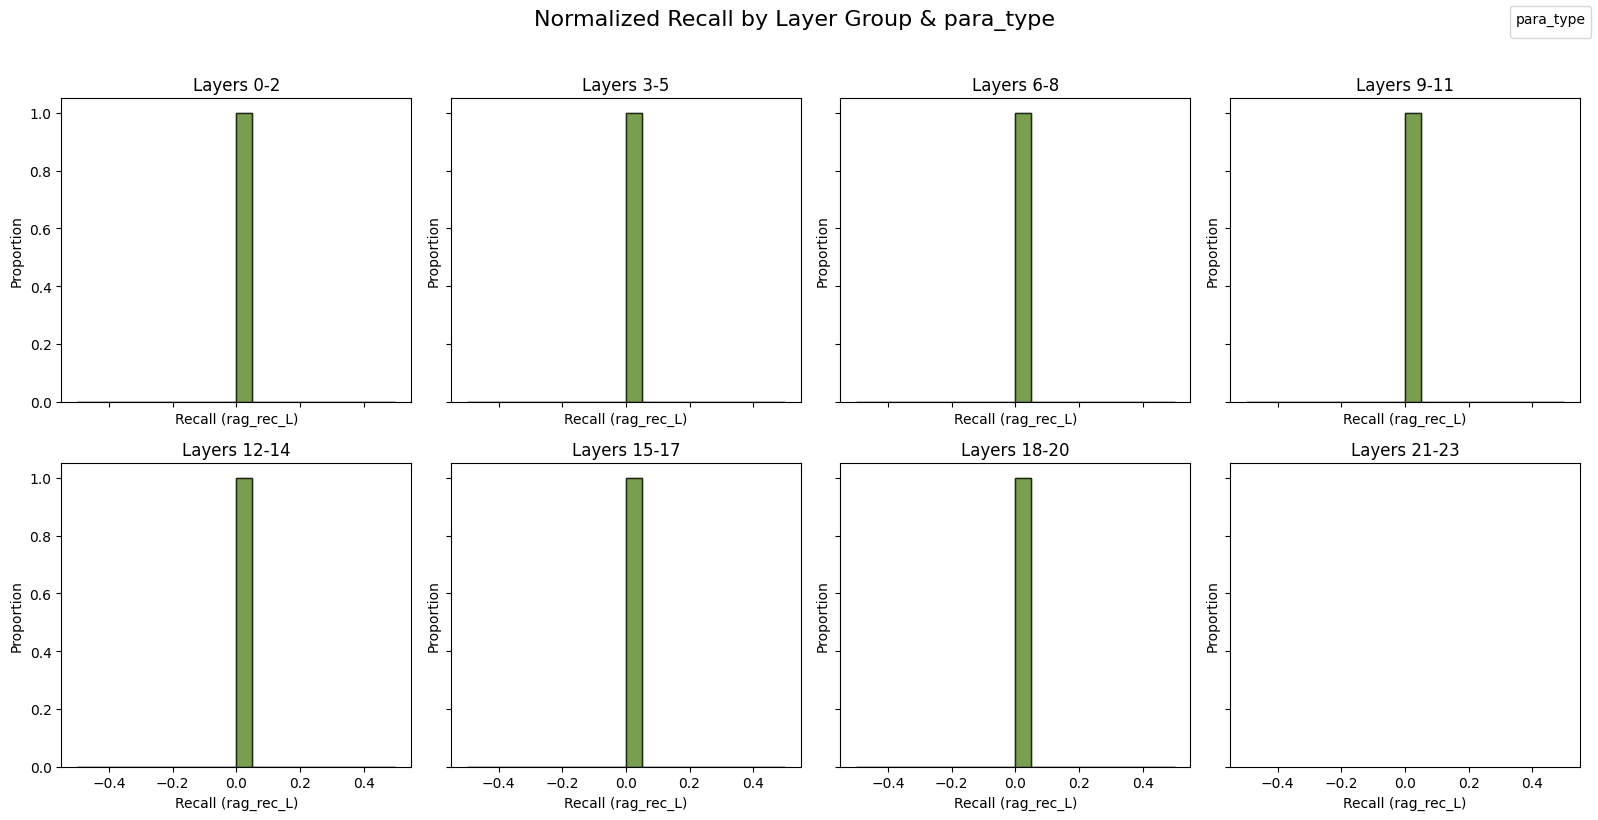

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Define your 3‐layer bin edges and labels
bins = list(range(0, 24, 3))               # [0, 3, 6, …, 21]
labels = [f"{i}-{i+2}" for i in bins]      # ["0-2","3-5",…,"21-23"]

# 2) Compute layer_group
df_false_sorted['layer_group'] = pd.cut(
    df_false_sorted['layer'],
    bins=bins + [bins[-1] + 3],  # [0,3,6,…,21,24]
    right=False,
    labels=labels
)

# 3) Now re‐extract your labels list from the categorical
labels = df_false_sorted['layer_group'].cat.categories.tolist()

# 4) Build your color map
para_types = df_false_sorted['para_type'].unique()
base_colors = plt.cm.tab10.colors
colors = base_colors[:len(para_types)]
color_map = dict(zip(para_types, colors))
print(color_map)
# 5) Plot!
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
for ax, grp in zip(axes.flatten(), labels):
    sub = df_false_sorted[df_false_sorted['layer_group'] == grp]
    for ptype in para_types:
        vals = sub.loc[sub['para_type'] == ptype, 'rag_rec_L'].dropna()
        if len(vals):
            weights = np.ones_like(vals) / len(vals)
            ax.hist(
                vals,
                bins=20,
                weights=weights,
                alpha=0.5,
                label=ptype,
                color=color_map[ptype],
                edgecolor='black',
                linewidth=1
            )
    ax.set_title(f"Layers {grp}")
    ax.set_xlabel('Recall (rag_rec_L)')
    ax.set_ylabel('Proportion')

# Legend and layout
handles, legend_labels = axes.flatten()[-1].get_legend_handles_labels()
fig.legend(handles, legend_labels, title='para_type')
plt.suptitle('Normalized Recall by Layer Group & para_type', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


In [209]:
df_filtered = df_filtered.iloc[:140]  
df_filtered = df_filtered[df_filtered['question_id'].isin(root_correct_qids)]
with open("temp_l19.txt", "w", encoding="utf-8") as f:
    for idx, row in df_filtered.iloc[:140].iterrows():
        f.write(f"{row['prompt']}\n")
        f.write(f"({row['rag_prec_L']}) ({row['layer']}) {row['para_type']}\n")
        f.write("closest match:\n" + str(list(c[0]['title'] for c in row['rag_closest_match'])))
        f.write(f"\n{row['possible_answers']}\n")
        f.write(f"{row['base_rag']}\n")
        f.write("=========================================\n")

In [150]:
df_false_sorted.iloc[100:130]

,gen_modelId,question_id,layer,para_type,prompt,rag_closest_match,possible_answers,rag_found_match,rag_f1_1,base_rec_1,base_rec_L,rag_rec_1,rag_rec_L,base_prec_1,base_prec_L,rag_prec_1,rag_prec_L,base_rag
15133,mistralai/Mistral-7B-Instruct-v0.2,13500,5,semantic,What was once a federation of only the heads o...,"[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,John Stewart Muller and Laura Boersma were the...
15134,mistralai/Mistral-7B-Instruct-v0.2,13500,4,question_position_suffix,Who was the producer of Fling? Sandvoss was bo...,"[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,John Stewart Muller and Laura Boersma were the...
15135,mistralai/Mistral-7B-Instruct-v0.2,13500,4,question_position_middle,"Sandvoss was born in New York City, New York. ...","[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,Laura Boersma and John Stewart Muller were the...
15136,mistralai/Mistral-7B-Instruct-v0.2,13500,6,semantic,"Wildflowers surround Old St. Hilary's, Tiburon...","[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,John Stewart Muller and Laura Boersma were the...
15137,mistralai/Mistral-7B-Instruct-v0.2,13500,5,question_position_suffix,Who was the producer of Fling? Sandvoss was bo...,"[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,John Stewart Muller and Laura Boersma were the...
15138,mistralai/Mistral-7B-Instruct-v0.2,13500,5,question_position_middle,"Sandvoss was born in New York City, New York. ...","[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,The producer of Fling was John Stewart Muller ...
15139,mistralai/Mistral-7B-Instruct-v0.2,13500,7,semantic,"East Bethany, NY: Trystan & Max Sandvoss. Wild...","[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,John Stewart Muller and Laura Boersma were the...
15140,mistralai/Mistral-7B-Instruct-v0.2,13500,6,question_position_suffix,Who was the producer of Fling? Sandvoss was bo...,"[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,John Stewart Muller and Laura Boersma were the...
15141,mistralai/Mistral-7B-Instruct-v0.2,13500,6,question_position_middle,"Sandvoss was born in New York City, New York. ...","[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,The producer of Fling was Laura Boersma.\n\nTh...
15142,mistralai/Mistral-7B-Instruct-v0.2,13500,8,semantic,The Coast Miwok Indians had lived here for tho...,"[({'title': 'Fling (film)', 'context': 'Title:...","[Brandon Routh, Brandon James Routh]",False,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,Laura Boersma and John Stewart Muller were the...


In [107]:
for idx, row in df_true_sorted.iloc[:30].iterrows():
    prompt = row["prompt"]
    layer = row["layer"]
    para_type = row.get("para_type", None)
    possible_answers = row.get("possible_answers")
    base_rag = row.get("base_rag")
    rag_f1_1 = row["rag_f1_1"]

    print(f"Row {idx}")
    print(f"rag_f1_1 {rag_f1_1}")
    print(f"  Prompt:           {prompt}")
    print(f"  Layer:            {layer}")
    print(f"  Paragraph Type:   {para_type}")
    print(f"  Possible Answers: {possible_answers}")
    print(f"  Base RAG response:   {base_rag}")
    print("-" * 50)


Row 17195
rag_f1_1 0.02580645161290323
  Prompt:           In what country is Cornville? Arizona is home to a diverse population. It has been estimated there are as many as 7.77 million animal species on Earth. Mesoamerica, considered a cradle of civilization, was home to numerous advanced societies, including the Olmecs, Maya, Zapotecs, Teotihuacan civilization, and Purépecha. A native-born Mexican of Basque ancestry established the ranchería (small rural settlement) of Arizona between 1734 and 1736 in the current Mexican state of Sonora. It is the largest living land animal in Asia and the second largest living elephantid in the world. The large ear flaps assist in maintaining a constant body temperature as well as in communication. Tusks, which are derived from the incisor teeth, serve both as weapons and as tools for moving objects and digging. The Standard Book Number (SBN) is a commercial system using nine-digit code numbers to identify books. Humans make use of many other animal

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

def plot_by_layer_smoothed(df, gen_models, title,
                           terminal_comparison=[],
                           plot_base=True,
                           window=3):
    fig, ax = plt.subplots(figsize=(10, 6))
    term_markers = ['d', '^', 's', 'v', 'P', '*']  # add as many as you need
    term_marker_cycle = itertools.cycle(term_markers)

    for model in gen_models:
        # select semantic rows
        df_model = df[(df['gen_modelId']==model) & (df['para_type']=="semantic")].copy()

        # compute percentages
        df_model['base_%'] = (
            df_model.base_found_match_True_count /
            (df_model.base_found_match_True_count + df_model.base_found_match_False_count)
        )*100
        df_model['rag_%'] = (
            df_model.base_found_rag_match_True_count /
            (df_model.base_found_rag_match_True_count + df_model.base_found_rag_match_False_count)
        )*100

        # define 3-layer bins: 0–2 → 1, 3–5 → 4, 6–8 → 7, …
        df_model['layer_bin'] = (df_model['layer'] // window)*window + (window-1)/2
        
        # average within each bin
        df_grp = (df_model
                  .groupby('layer_bin')
                  .agg(base_pct=('base_%','mean'),
                       rag_pct=('rag_%','mean'))
                  .reset_index())

        color = model_colors.get(model, 'black')

        if plot_base:
            ax.plot(df_grp.layer_bin, df_grp.base_pct,
                    marker='o', linestyle='-',
                    color=color,
                    label=f'{model.split("/")[-1]} base (3-avg)')

        ax.plot(df_grp.layer_bin, df_grp.rag_pct,
                marker='x', linestyle='--',
                color=color,
                label=f'{model.split("/")[-1]} base_rag (3-avg)')

        # any terminal comparisons
        for term in terminal_comparison:
            df_term = df[(df['gen_modelId']==model) & (df['para_type']==term)].copy()
            if df_term.empty:
                continue
            df_term['rag_%'] = (
                df_term.base_found_rag_match_True_count /
                (df_term.base_found_rag_match_True_count + df_term.base_found_rag_match_False_count)
            )*100
            df_term['layer_bin'] = (df_term['layer'] // window)*window + (window-1)/2
            df_tgrp = (df_term
                       .groupby('layer_bin')
                       .agg(rag_pct=('rag_%','mean'))
                       .reset_index())
            marker = next(term_marker_cycle)
            ax.plot(
                df_tgrp.layer_bin,
                df_tgrp.rag_pct,
                marker=marker,
                linestyle='-',      # solid line
                color=color,        # same color as the model
                label=f'{model.split("/")[-1]} {term} (3-avg)'
            )

    ax.set_xlabel('Layer (binned over 3)')
    ax.set_ylabel('Correct Answer % (smoothed)')
    ax.set_title(f'{title} — 3-layer moving averages')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


In [109]:
import os
tree_ids = []
for filename in os.listdir('/vol/bitbucket/lst20/long_POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/tree/'):
    if filename.endswith(".pkl"):
        tree_ids.append(int(filename[: -len(".pkl")]))
print(tree_ids[:4])

[3241, 1514, 8952, 10152]



 _____ _____ _____ _____ _____ 
|  _  |     |  _  |     |  _  |
|   __|  |  |   __|  |  |     |
|__|  |_____|__|  |__  _|__|__|
                    |__|                                    
    
/vol/bitbucket/lst20/POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 725
google/gemma-3-12b-it df len: 10872
/vol/bitbucket/lst20/POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 725
google/gemma-3-1b-it df len: 10872
/vol/bitbucket/lst20/POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 540
mistralai/Mistral-7B-Instruct-v0.2 df len: 8099

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 22.206897     76.275862
     1 21.241379     75.655172
     2 22.931034     75.275862
     3 22.994652     74.935311

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.6207
  Layer 2: Drop = -0.3793
  Layer 3: Drop = 

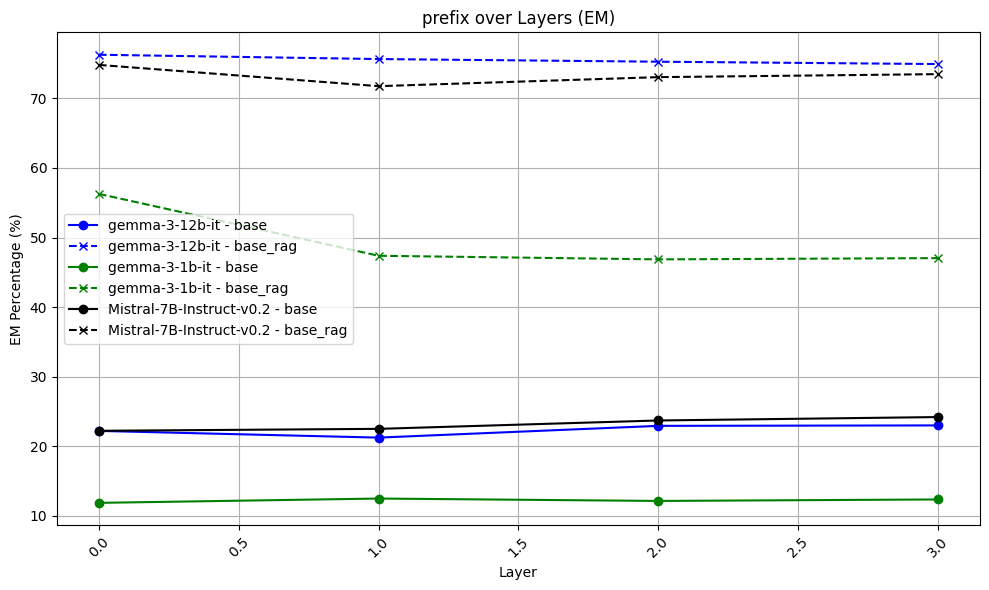


gemma-3-12b-it Scores by Layer:
 layer  base_prec_1  rag_prec_1
     0     0.241331    0.616895
     1     0.231496    0.629283
     2     0.243777    0.642854
     3     0.242536    0.654406

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0124
  Layer 2: Drop = 0.0136
  Layer 3: Drop = 0.0116

gemma-3-1b-it Scores by Layer:
 layer  base_prec_1  rag_prec_1
     0     0.111258    0.191568
     1     0.083401    0.107764
     2     0.081375    0.086396
     3     0.080953    0.077714

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0838
  Layer 2: Drop = -0.0214
  Layer 3: Drop = -0.0087

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_prec_1  rag_prec_1
     0     0.094636    0.353143
     1     0.059807    0.356779
     2     0.065785    0.365790
     3     0.073039    0.374528

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0036
  Layer 2: Drop = 0.0090
  Lay

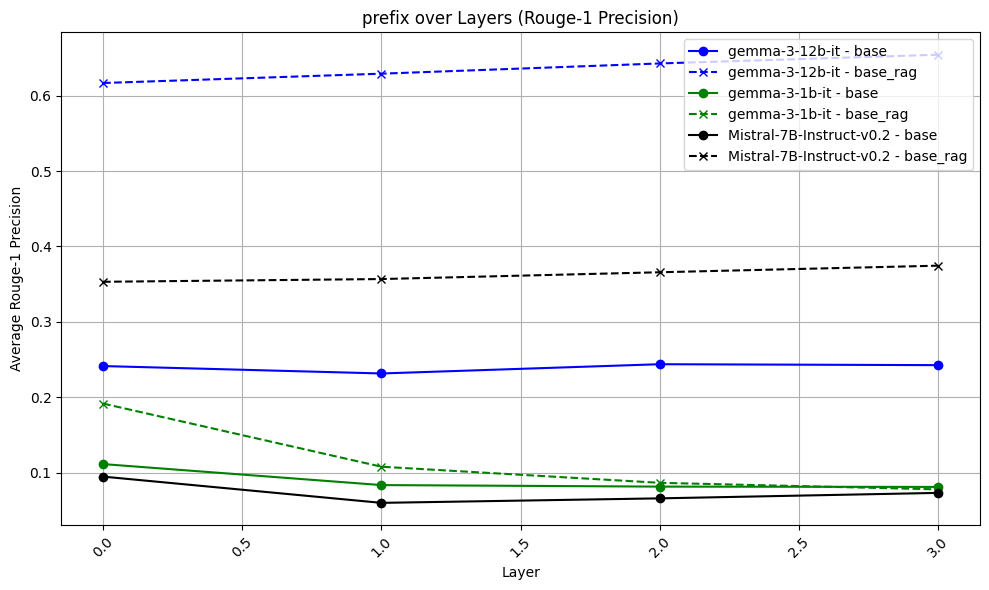


gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.254644   0.819751
     1    0.243644   0.819969
     2    0.261828   0.814153
     3    0.258823   0.810251

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0002
  Layer 2: Drop = -0.0058
  Layer 3: Drop = -0.0039

gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.135985   0.627149
     1    0.138736   0.530816
     2    0.142392   0.527611
     3    0.144732   0.528230

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0963
  Layer 2: Drop = -0.0032
  Layer 3: Drop = 0.0006

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.286883   0.804630
     1    0.273714   0.773328
     2    0.284108   0.785159
     3    0.288989   0.791086

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0313
  Layer 2: Drop = 0.0118
  Layer 3: Drop = 0.0059


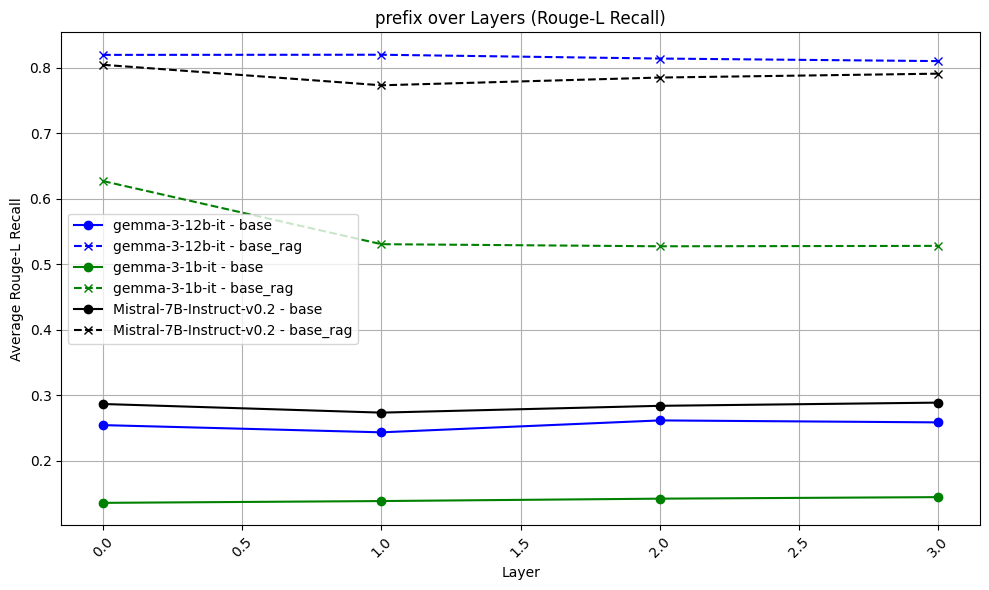


gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.240135  0.654107
     1   0.229825  0.664704
     2   0.242851  0.675868
     3   0.241879  0.683437

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0106
  Layer 2: Drop = 0.0112
  Layer 3: Drop = 0.0076

gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.114049  0.263675
     1   0.090321  0.163848
     2   0.089005  0.137204
     3   0.089398  0.124319

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0998
  Layer 2: Drop = -0.0266
  Layer 3: Drop = -0.0129

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.121496  0.419464
     1   0.085103  0.419560
     2   0.091796  0.428332
     3   0.099358  0.437659

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0001
  Layer 2: Drop = 0.0088
  Layer 3: Drop = 0.0093


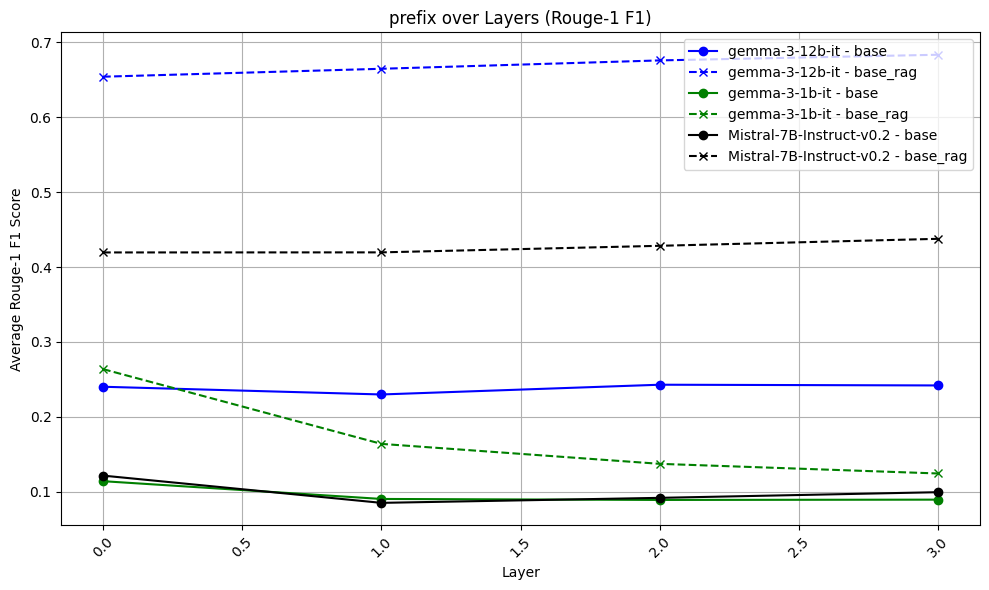


gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.239708  0.653134
     1   0.229287  0.664371
     2   0.242479  0.675447
     3   0.241260  0.683009

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0112
  Layer 2: Drop = 0.0111
  Layer 3: Drop = 0.0076

gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.113845  0.261198
     1   0.089960  0.162365
     2   0.088618  0.135392
     3   0.088826  0.122211

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0988
  Layer 2: Drop = -0.0270
  Layer 3: Drop = -0.0132

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.120386  0.417682
     1   0.083581  0.418165
     2   0.090225  0.426396
     3   0.097816  0.435769

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0005
  Layer 2: Drop = 0.0082
  Layer 3: Drop = 0.0094


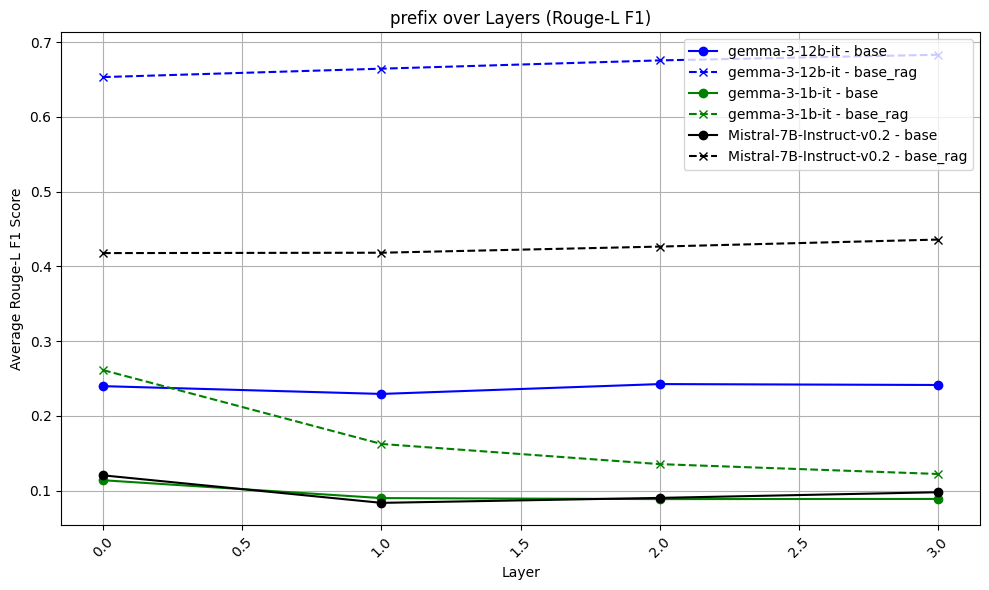

            
 _____ _____ _____ 
|_   _|     |  _  |
  | | |  |  |     |
  |_| |__  _|__|__|
         |__|      
    
/vol/bitbucket/lst20/TQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 608
google/gemma-3-12b-it df len: 9108
/vol/bitbucket/lst20/TQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 608
google/gemma-3-1b-it df len: 9108
/vol/bitbucket/lst20/TQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 608
mistralai/Mistral-7B-Instruct-v0.2 df len: 9108

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 55.263158     56.907895
     1 52.181070     55.802469
     2 54.178674     55.290243
     3 53.191928     55.333608

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -1.1054
  Layer 2: Drop = -0.5122
  Layer 3: Drop = 0.0434

gemma-3-1b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 14.63815

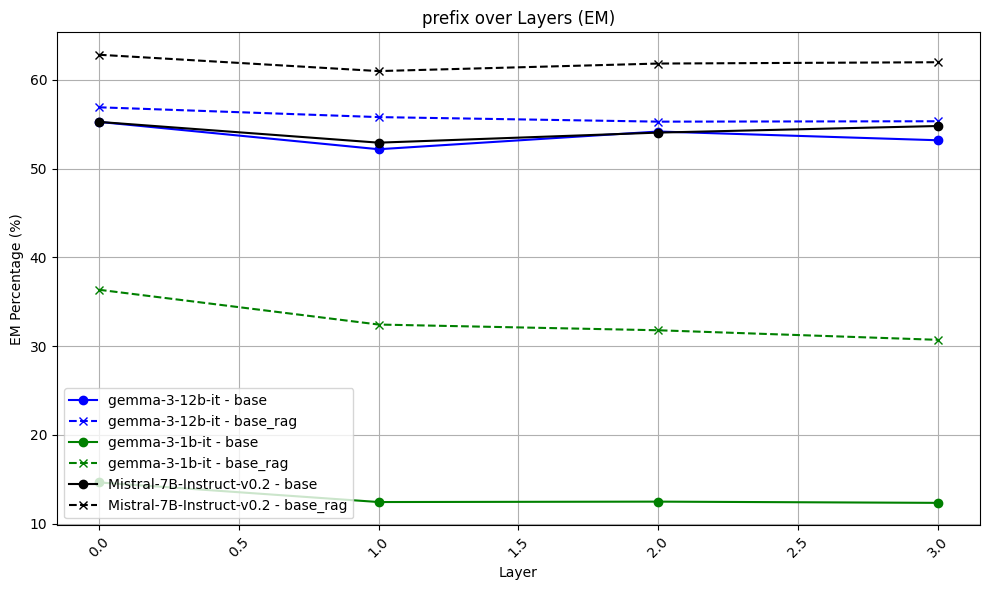


gemma-3-12b-it Scores by Layer:
 layer  base_prec_1  rag_prec_1
     0     0.577728    0.462616
     1     0.545107    0.473686
     2     0.559039    0.471073
     3     0.546489    0.476294

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0111
  Layer 2: Drop = -0.0026
  Layer 3: Drop = 0.0052

gemma-3-1b-it Scores by Layer:
 layer  base_prec_1  rag_prec_1
     0     0.135565    0.088003
     1     0.097740    0.045917
     2     0.085520    0.039732
     3     0.080894    0.031609

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0421
  Layer 2: Drop = -0.0062
  Layer 3: Drop = -0.0081

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_prec_1  rag_prec_1
     0     0.204754    0.233376
     1     0.168450    0.238428
     2     0.158393    0.253630
     3     0.161443    0.252235

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0051
  Layer 2: Drop = 0.0152
  La

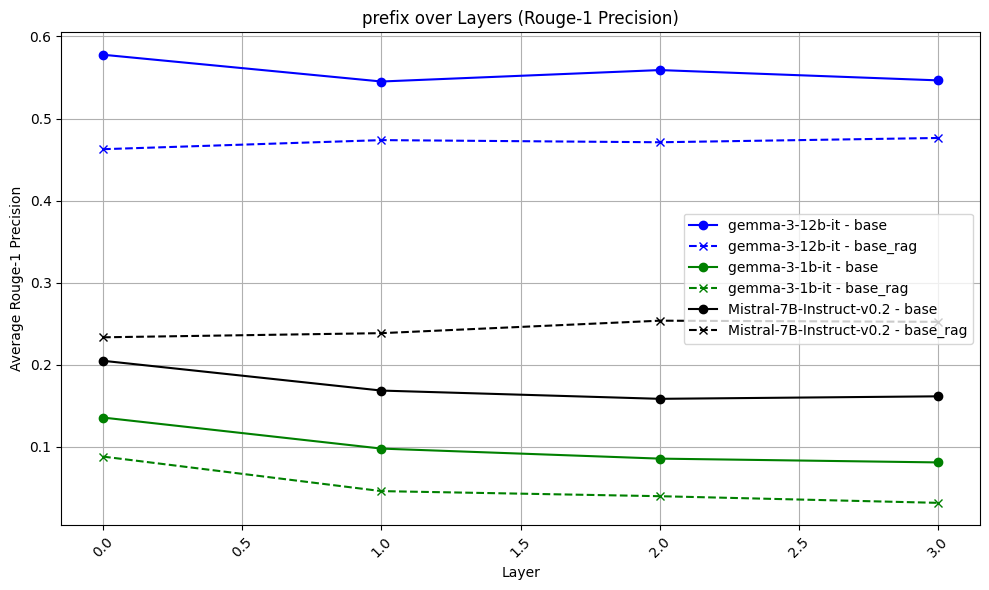


gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.616181   0.629887
     1    0.584795   0.617821
     2    0.605674   0.611123
     3    0.594941   0.615209

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0121
  Layer 2: Drop = -0.0067
  Layer 3: Drop = 0.0041

gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.194568   0.430631
     1    0.166469   0.385887
     2    0.164711   0.380445
     3    0.164880   0.366030

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0447
  Layer 2: Drop = -0.0054
  Layer 3: Drop = -0.0144

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.627111   0.692058
     1    0.600778   0.673862
     2    0.612562   0.683900
     3    0.615325   0.684741

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0182
  Layer 2: Drop = 0.0100
  Layer 3: Drop = 0.0008


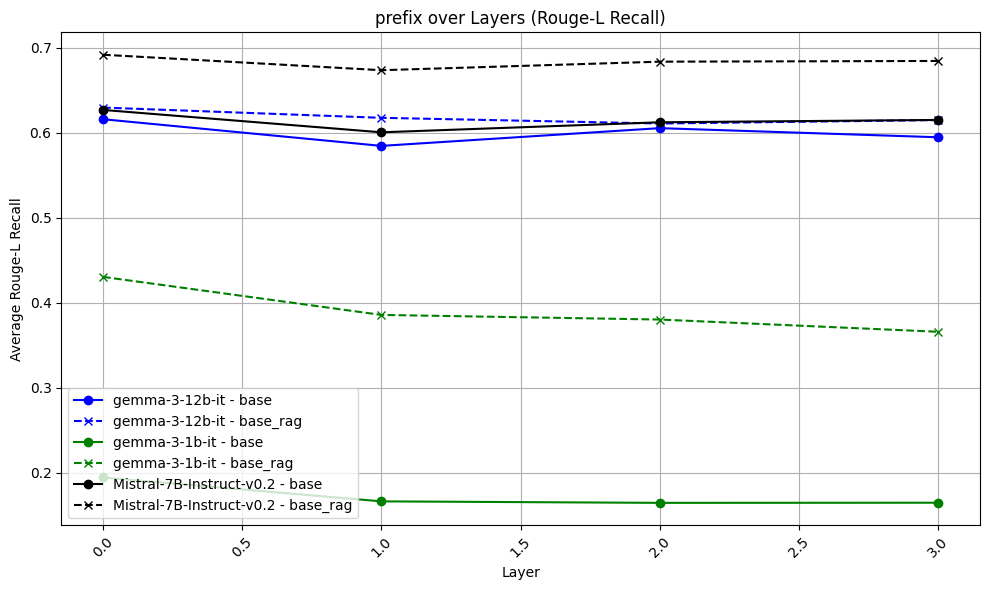


gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.584140  0.494291
     1   0.548714  0.497526
     2   0.563502  0.493678
     3   0.549674  0.498533

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0032
  Layer 2: Drop = -0.0038
  Layer 3: Drop = 0.0049

gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.145773  0.123676
     1   0.108505  0.073658
     2   0.097009  0.063477
     3   0.093326  0.051017

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0500
  Layer 2: Drop = -0.0102
  Layer 3: Drop = -0.0125

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.253130  0.275925
     1   0.210540  0.280844
     2   0.199907  0.295947
     3   0.202210  0.294348

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0049
  Layer 2: Drop = 0.0151
  Layer 3: Drop = -0.0016


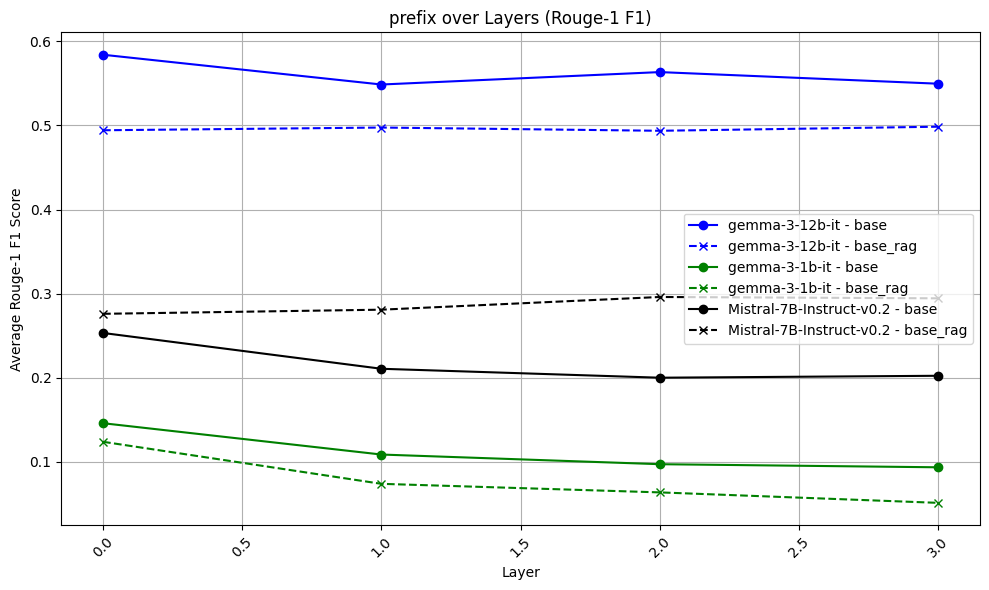


gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.582358  0.493757
     1   0.547891  0.497038
     2   0.562431  0.493048
     3   0.548730  0.498058

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0033
  Layer 2: Drop = -0.0040
  Layer 3: Drop = 0.0050

gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.145773  0.122904
     1   0.108348  0.073143
     2   0.096941  0.062955
     3   0.093025  0.050815

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0498
  Layer 2: Drop = -0.0102
  Layer 3: Drop = -0.0121

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.252817  0.275296
     1   0.209270  0.280240
     2   0.198709  0.295566
     3   0.201027  0.293881

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0049
  Layer 2: Drop = 0.0153
  Layer 3: Drop = -0.0017


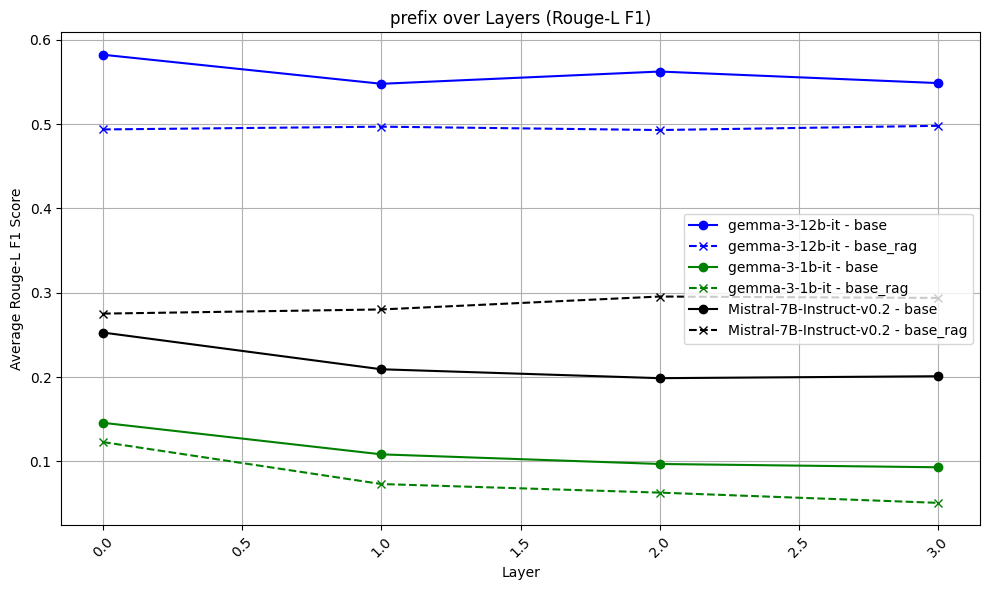

In [3]:
datasets = ["POPQA", "TQA"]
for dataset in datasets:
  print(constants.dataset_fancy_text[dataset])
  dfs_para_ = []
  for model in gen_models:
      try:
          df = read_trees_to_df("prefix", model, dataset)
          print(f"tree count: {df["question_id"].nunique()}")
          print(f"{model} df len: {len(df)}")
          dfs_para_.append(df)
      except KeyError as e:
          print(e)

  df_para_ = pd.concat(dfs_para_, ignore_index=True)
  # df_para_ = get_perplexity(df_para_)
  df_para_.to_csv(f"analysis/df_prefix_{dataset}_.csv")
  # perform groupby and aggregation
  df_grouped_para_ = agg_df(df_para_)
  df_grouped_para_.columns
  plot_by_layer(df_grouped_para_, gen_models, title="prefix")
  plot_by_layer(df_grouped_para_, gen_models, title="prefix", plot='prec_ROUGE_1')
  plot_by_layer(df_grouped_para_, gen_models, title="prefix", plot='recall_ROUGE_L')
  plot_by_layer(df_grouped_para_, gen_models, title="prefix", plot='f1_ROUGE_1')
  plot_by_layer(df_grouped_para_, gen_models, title="prefix", plot='f1_ROUGE_L')


 _____ _____ _____ _____ _____ 
|  _  |     |  _  |     |  _  |
|   __|  |  |   __|  |  |     |
|__|  |_____|__|  |__  _|__|__|
                    |__|                                    
    
/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 591
google/gemma-3-12b-it df len: 7976
/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 560
google/gemma-3-1b-it df len: 7565
/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 475
mistralai/Mistral-7B-Instruct-v0.2 df len: 6459

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 21.658206     75.634518
     1 22.012579     72.776280
     2 21.622868     71.046565
     3 21.667073     71.191811

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -2.8582
  Layer 2: Drop = -1.7297
  Lay

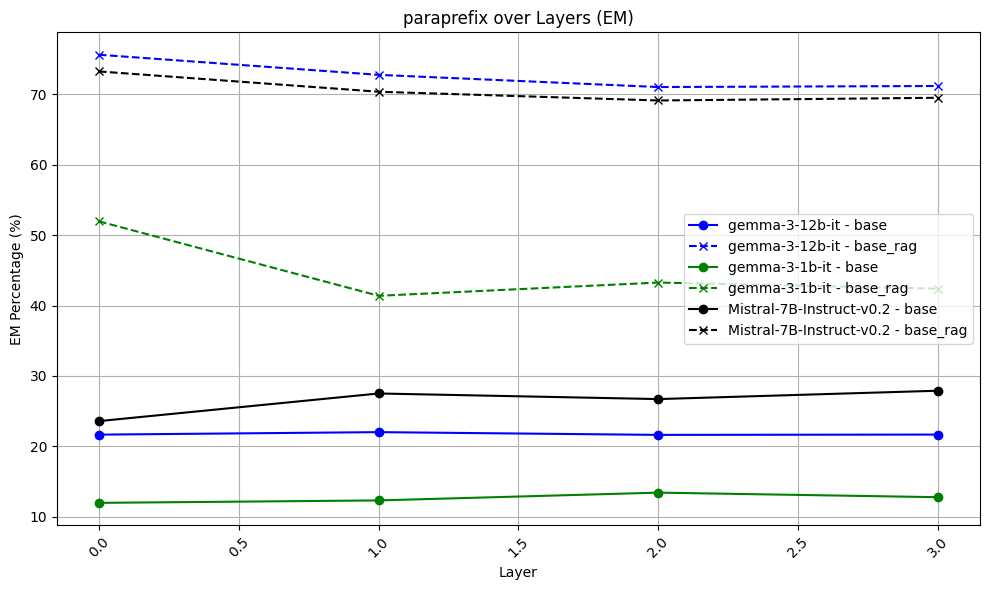


gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.227298  0.632731
     1   0.219833  0.560487
     2   0.213782  0.584582
     3   0.215516  0.603484

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0722
  Layer 2: Drop = 0.0241
  Layer 3: Drop = 0.0189

gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.110672  0.242432
     1   0.081226  0.110119
     2   0.090838  0.101230
     3   0.086501  0.087441

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1323
  Layer 2: Drop = -0.0089
  Layer 3: Drop = -0.0138

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.119403  0.404982
     1   0.099746  0.300243
     2   0.096280  0.318800
     3   0.105613  0.349646

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1047
  Layer 2: Drop = 0.0186
  Layer 3: Drop = 0.0308


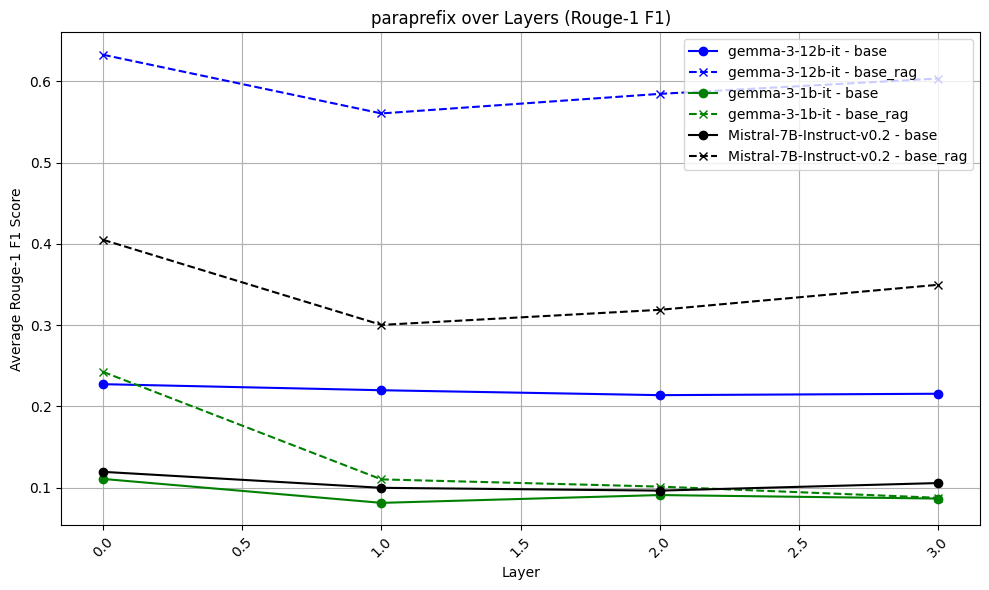


gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.227177  0.631216
     1   0.219313  0.559401
     2   0.213124  0.583378
     3   0.215296  0.602217

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0718
  Layer 2: Drop = 0.0240
  Layer 3: Drop = 0.0188

gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.110407  0.240517
     1   0.080627  0.108851
     2   0.090464  0.099218
     3   0.085789  0.086391

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1317
  Layer 2: Drop = -0.0096
  Layer 3: Drop = -0.0128

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.116898  0.402132
     1   0.097858  0.297575
     2   0.094606  0.316388
     3   0.103590  0.346748

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1046
  Layer 2: Drop = 0.0188
  Layer 3: Drop = 0.0304


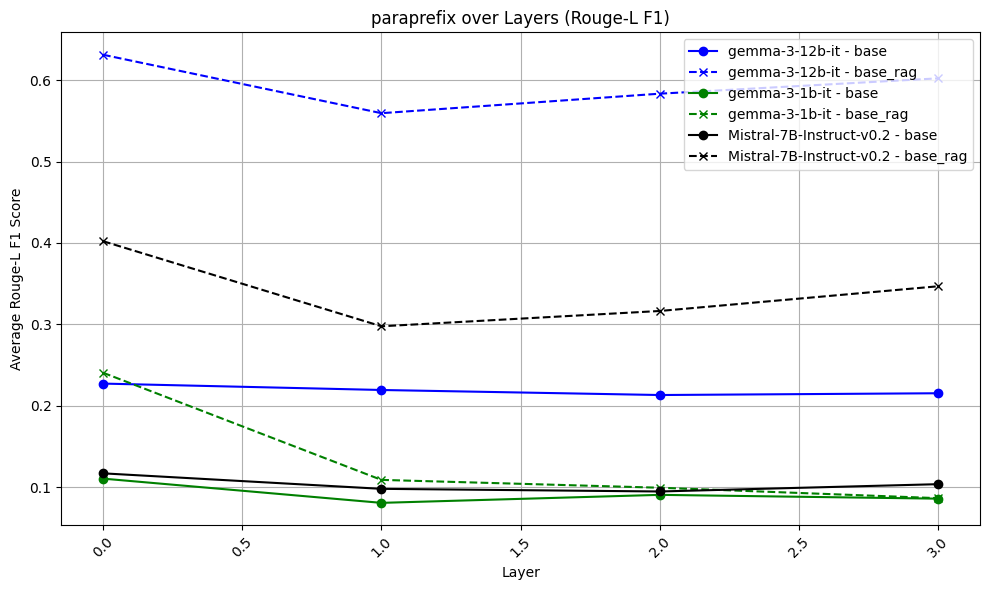


gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.246672   0.816248
     1    0.248997   0.786094
     2    0.242528   0.762315
     3    0.239079   0.763643

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0302
  Layer 2: Drop = -0.0238
  Layer 3: Drop = 0.0013

gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.138254   0.577232
     1    0.139560   0.470712
     2    0.152347   0.489772
     3    0.148589   0.481476

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.1065
  Layer 2: Drop = 0.0191
  Layer 3: Drop = -0.0083

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.290807   0.800351
     1    0.309884   0.766549
     2    0.315104   0.750823
     3    0.323431   0.749663

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0338
  Layer 2: Drop = -0.0157
  Layer 3: Drop = -0.0012


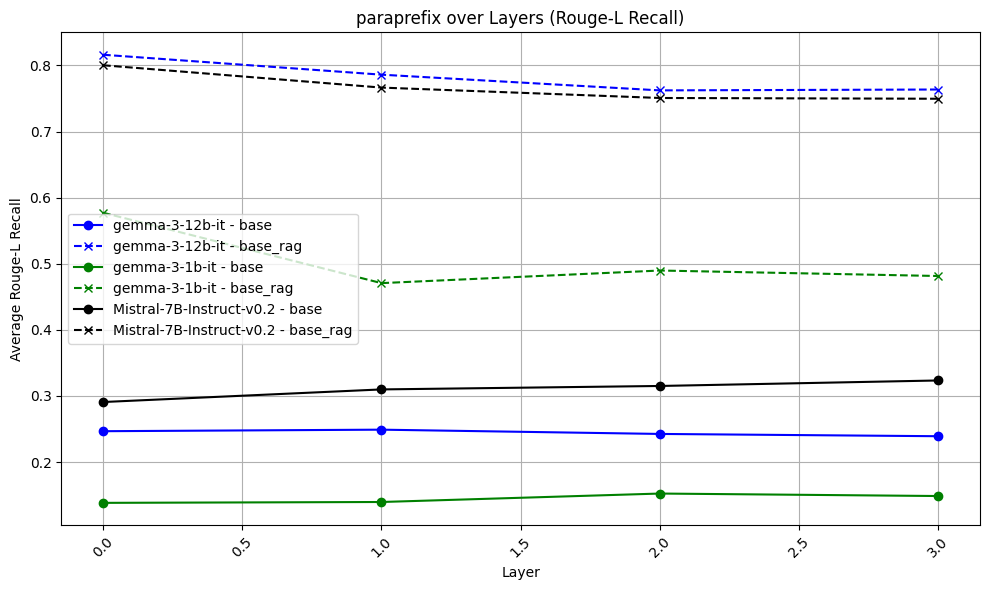

            
 _____ _____ _____ 
|_   _|     |  _  |
  | | |  |  |     |
  |_| |__  _|__|__|
         |__|      
    
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 555
google/gemma-3-12b-it df len: 7100
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 555
google/gemma-3-1b-it df len: 7100
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 376
mistralai/Mistral-7B-Instruct-v0.2 df len: 4889

gemma-3-12b-it Scores by Layer:
 layer  base_pct  base_rag_pct
     0 54.054054     58.198198
     1 48.118812     56.138614
     2 49.584631     54.465213
     3 48.877805     54.308673

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -2.0596
  Layer 2: Drop = -1.6734
  Layer 3: Drop = -0.1565

gemma-3-1b-it Scores by Layer:
 layer  base_pct  base_rag_pct

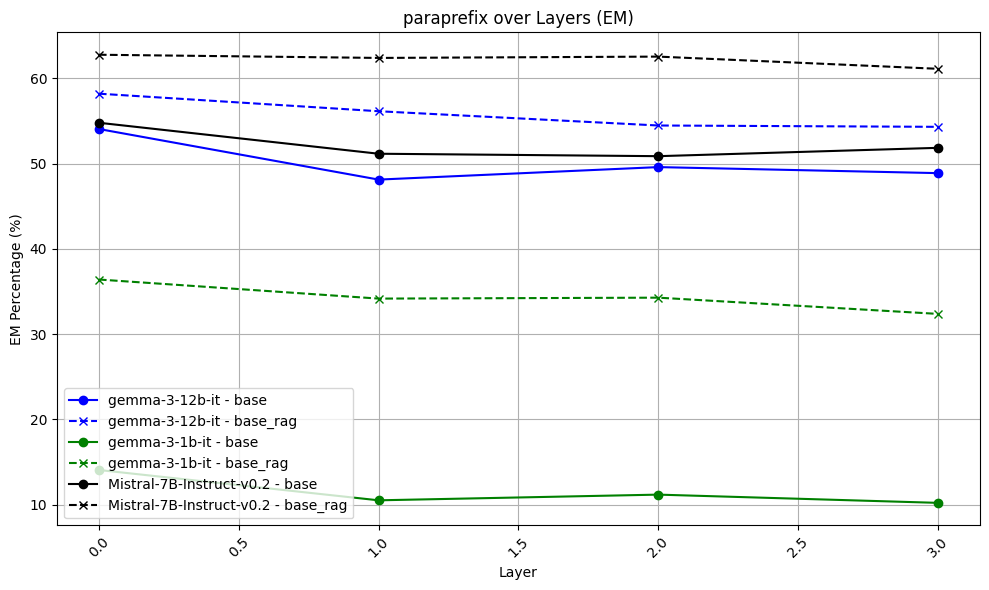


gemma-3-12b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.575841  0.498446
     1   0.494423  0.483376
     2   0.505485  0.464770
     3   0.496720  0.471426

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0151
  Layer 2: Drop = -0.0186
  Layer 3: Drop = 0.0067

gemma-3-1b-it Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.137520  0.123750
     1   0.086027  0.073174
     2   0.081841  0.061401
     3   0.077533  0.050689

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0506
  Layer 2: Drop = -0.0118
  Layer 3: Drop = -0.0107

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_1  rag_f1_1
     0   0.242065  0.271253
     1   0.205767  0.294018
     2   0.189769  0.288606
     3   0.211769  0.288314

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0228
  Layer 2: Drop = -0.0054
  Layer 3: Drop = -0.0003


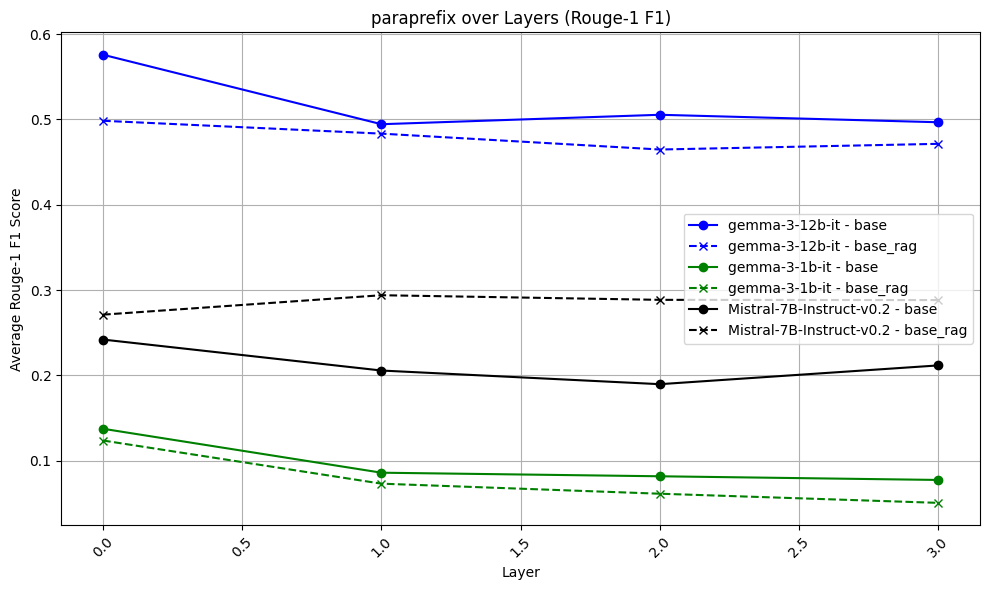


gemma-3-12b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.573889  0.498005
     1   0.492135  0.482261
     2   0.504139  0.464099
     3   0.495564  0.470822

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0157
  Layer 2: Drop = -0.0182
  Layer 3: Drop = 0.0067

gemma-3-1b-it Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.137520  0.122979
     1   0.086027  0.072771
     2   0.081661  0.060675
     3   0.077157  0.050149

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0502
  Layer 2: Drop = -0.0121
  Layer 3: Drop = -0.0105

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_f1_L  rag_f1_L
     0   0.241702  0.270330
     1   0.205066  0.293560
     2   0.188741  0.287941
     3   0.210824  0.287578

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0232
  Layer 2: Drop = -0.0056
  Layer 3: Drop = -0.0004


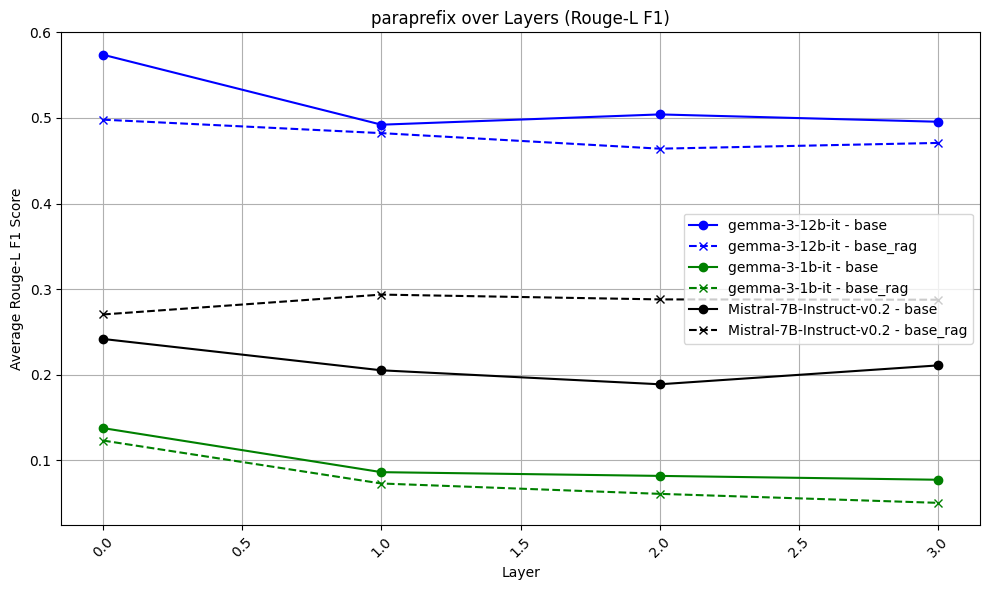


gemma-3-12b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.604753   0.639438
     1    0.545983   0.619008
     2    0.560584   0.603884
     3    0.549208   0.600976

RAG Drop per layer for gemma-3-12b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0204
  Layer 2: Drop = -0.0151
  Layer 3: Drop = -0.0029

gemma-3-1b-it Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.188825   0.434264
     1    0.150215   0.403039
     2    0.151351   0.405668
     3    0.145556   0.387924

RAG Drop per layer for gemma-3-1b-it:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = -0.0312
  Layer 2: Drop = 0.0026
  Layer 3: Drop = -0.0177

Mistral-7B-Instruct-v0.2 Scores by Layer:
 layer  base_rec_L  rag_rec_L
     0    0.619681   0.681244
     1    0.569154   0.686476
     2    0.571305   0.683809
     3    0.578852   0.669139

RAG Drop per layer for Mistral-7B-Instruct-v0.2:
  Layer 0: Drop = 0.0000
  Layer 1: Drop = 0.0052
  Layer 2: Drop = -0.0027
  Layer 3: Drop = -0.0147


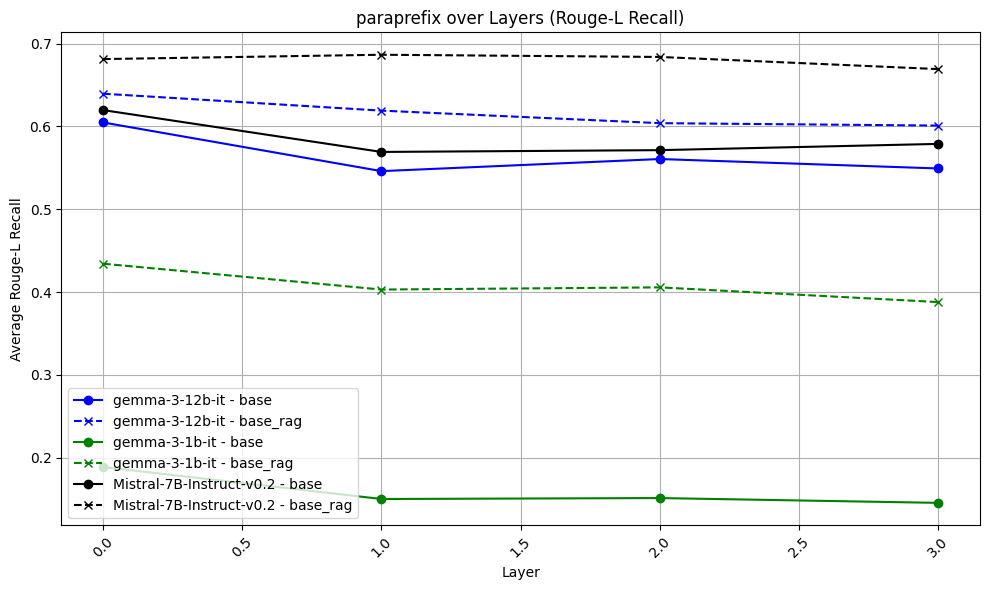

In [6]:
datasets = ["POPQA", "TQA"]
for dataset in datasets:
  print(constants.dataset_fancy_text[dataset])
  dfs_para_ = []
  for model in gen_models:
      try:
          df = read_trees_to_df("paraphrase_then_prefix", model, dataset)
          print(f"tree count: {df["question_id"].nunique()}")
          print(f"{model} df len: {len(df)}")
          dfs_para_.append(df)
      except KeyError as e:
          print(e)

  df_para_ = pd.concat(dfs_para_, ignore_index=True)
  # df_para_ = get_perplexity(df_para_)
  df_para_.to_csv(f"analysis/df_paraprefix_{dataset}_.csv")
  # perform groupby and aggregation
  df_grouped_para_ = agg_df(df_para_)
  df_grouped_para_.columns
  plot_by_layer(df_grouped_para_, gen_models, title="paraprefix")
  plot_by_layer(df_grouped_para_, gen_models, title="paraprefix", plot='f1_ROUGE_1')
  plot_by_layer(df_grouped_para_, gen_models, title="paraprefix", plot='f1_ROUGE_L')
  plot_by_layer(df_grouped_para_, gen_models, title="paraprefix", plot='recall_ROUGE_L')

In [215]:
# Copy the DataFrame and drop specified columns
length_df_copy = df_para_.copy()
cols_to_drop = [
    'type', 'wiki_title', 'rag_entities', "base_f1_1",	"base_f1_L", "base_found_match", "type", "id", "root_similarity_score", "complexity_score", 'fk_score',
    'fk_score', 'similarity', "metadata", 'dc_score', 'rag_f1_L', 'base'
]
length_df_copy = length_df_copy.drop(columns=cols_to_drop)

# Create sorted copies based on rag_found_match
# 1. Find all question_ids where the root (layer 0) was correct
# 1. Find all question_ids where the root (layer 0) was correct
question_ids = (
    length_df_copy
    .loc[
        (length_df_copy['layer'] == 0)     # only the root row
      & (length_df_copy['rag_rec_L'] == 1)  # perfect recall at root
      & (length_df_copy['rag_prec_L'] > 0) # some precision at root
      , # some precision at root
        'question_id'
    ]
    .tolist()   # <-- turn the Series into a Python list
)

# 2a. if you don't care about order, use a set:
root_correct_qids = list(set(question_ids))

# 2b. if you want to preserve the first‐seen order, use dict.fromkeys():
root_correct_qids = list(dict.fromkeys(question_ids))

# 2. Build your false‐sorted set as before…
df_false_sorted = (
    length_df_copy
    .loc[
      (length_df_copy['gen_modelId'] == 'mistralai/Mistral-7B-Instruct-v0.2')
    ]
    .sort_values(by='rag_prec_L', ascending=False)
)

# 3. Keep only those rows whose question_id was in the “root-correct” set
df_filtered = df_false_sorted[
    df_false_sorted['question_id'].isin(root_correct_qids)
]
df_filtered.iloc[:5]


,gen_modelId,question_id,layer,para_type,prompt,rag_closest_match,possible_answers,rag_found_match,rag_f1_1,base_rec_1,base_rec_L,rag_rec_1,rag_rec_L,base_prec_1,base_prec_L,rag_prec_1,rag_prec_L,base_rag
2273,mistralai/Mistral-7B-Instruct-v0.2,39972,2,semantic,The tribe were in extended conflict with their...,"[({'title': 'Dover, Delaware', 'context': 'Tit...",[DELAWARE],True,1.0,1.0,1.0,1.0,1.0,0.020833,0.020833,1.0,1.0,Delaware
1923,mistralai/Mistral-7B-Instruct-v0.2,597,0,semantic,Which 60s pop band made an unsuccessful movie ...,"[({'title': 'Head (film)', 'context': 'Title: ...",[The Monkees],True,1.0,1.0,1.0,1.0,1.0,0.200000,0.200000,1.0,1.0,The Monkees
1703,mistralai/Mistral-7B-Instruct-v0.2,8041,3,semantic,Following a severe storm in 1777 the River Hol...,"[({'title': 'Last of the Summer Wine', 'contex...",[Last of the Summer Wine],True,1.0,0.4,0.4,1.0,1.0,0.026316,0.026316,1.0,1.0,Last of the Summer Wine
1705,mistralai/Mistral-7B-Instruct-v0.2,8041,3,semantic,Holmfirth (and the surrounding countryside) is...,"[({'title': 'Last of the Summer Wine', 'contex...",[Last of the Summer Wine],True,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,Last of the Summer Wine
1880,mistralai/Mistral-7B-Instruct-v0.2,19367,3,semantic,"Colloquial names for Australia include ""Oz"", ""...","[({'title': 'Harry Nicolaides', 'context': 'Ti...",[Thailand],True,1.0,0.0,0.0,1.0,1.0,0.000000,0.000000,1.0,1.0,Thailand


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def generate_rag_comparison(
    df: pd.DataFrame,
    by_layer: bool = False,
) -> pd.DataFrame:
    """
    Compute counts of how questions changed from base→RAG.
    """
    df_temp = df.copy()
    df_temp['deteriorated']     = ((df_temp['base_found_match']) & (~df_temp['base_found_rag_match'])).astype(int)
    df_temp['improved']         = ((~df_temp['base_found_match']) & (df_temp['base_found_rag_match'])).astype(int)
    df_temp['stable_correct']   = ((df_temp['base_found_match']) & (df_temp['base_found_rag_match'])).astype(int)
    df_temp['stable_incorrect'] = ((~df_temp['base_found_match']) & (~df_temp['base_found_rag_match'])).astype(int)

    group_cols = []
    group_cols.append('gen_modelId')
    if by_layer:
        group_cols.append('layer')

    if group_cols:
        return (
            df_temp
            .groupby(group_cols)[
                ['deteriorated', 'improved', 'stable_correct', 'stable_incorrect']
            ]
            .sum()
            .reset_index()
        )
    else:
        sums = df_temp[['deteriorated', 'improved', 'stable_correct', 'stable_incorrect']].sum()
        return pd.DataFrame([sums])


def plot_models_by_layer(
    stats_df: pd.DataFrame,
    title: str,
    model_colors: dict,
    normalized: bool = False
):
    """
    Plots the four RAG‐change categories in a 1×4 grid of bar charts.

    """
    cats = ['deteriorated','improved','stable_correct','stable_incorrect']
    titles = {
        'deteriorated':     'Deteriorated\n(correct→incorrect)',
        'improved':         'Improved\n(incorrect→correct)',
        'stable_correct':   'Stable Correct\n(correct→correct)',
        'stable_incorrect': 'Stable Incorrect\n(incorrect→incorrect)'
    }
    
    df = stats_df.copy()
    if normalized:
        # convert each category to percent of total per row
        total = df[cats].sum(axis=1)
        df[cats] = df[cats].div(total, axis=0) * 100

    models = list(df['gen_modelId'].unique())
    n_models = len(models)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    
    for ax, cat in zip(axes, cats):
        # pivot so rows=layer, cols=model
        pivot = df.pivot(index='layer', columns='gen_modelId', values=cat)
        layers = pivot.index.astype(str).tolist()
        x = np.arange(len(layers))
        total_width = 0.8
        bar_width = total_width / n_models

        for i, model in enumerate(models):
            ys = pivot.get(model, pd.Series(0, index=pivot.index)).values
            color = model_colors.get(model, None)
            ax.bar(
                x + i*bar_width,
                ys,
                bar_width,
                label=model.split('/')[-1],
                color=color
            )

        ax.set_xticks(x + total_width/2 - bar_width/2)
        ax.set_xticklabels(layers, rotation=45, ha='right')
        ax.set_title(titles[cat])
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        if normalized:
            ax.set_ylabel('Percentage of Questions (%)')
        else:
            ax.set_ylabel('Count of Questions')

    # shared legend (only once)
    axes[-1].legend(title='Model', loc='upper right', fontsize='small')
    fig.suptitle(f'RAG Change fro {title} by Model & Layer', fontsize=18)
    plt.tight_layout()
    plt.show()


In [113]:
import pandas as pd
from pathlib import Path

def compute_strategy_rag_mismatch(
    strategy: str,
    gen_modelIds: list[str]
) -> tuple[float, pd.DataFrame]:
    """
    For a given strategy and list of gen_modelIds:
      - Load every *_checked.pkl tree  
      - Flag it as “bad” if:
          1) len(tree.rag_closest_match) != 4  
          2) AND none of the rag answers come from this strategy+model combo
      - Return:
          overall_rate : float
            Fraction of ALL trees (across all models) flagged bad.
          per_model_df : pd.DataFrame
            Columns ['gen_modelId','mismatch_rate'] giving each model’s rate.
    """
    # read your shuffled index once
    df_idx = pd.read_csv(constants.SHUFFLED_FILE)
    strategy_path = constants.STRATEGY_PATH_DICT[strategy]

    all_flags = []
    per_model = []

    for model in gen_modelIds:
        combo_tag = f"{strategy}-{model}"
        dir_name  = model.replace('/', '-')
        tree_dir  = Path(
            f"/vol/bitbucket/lst20/treenodes/"
            f"{strategy_path}/gemma3-12b_perturb/3_2_0/"
            f"{dir_name}/complete/"
        )

        bad_flags = []
        for idx in df_idx['original_index']:
            pkl = tree_dir / f"{idx}_checked.pkl"
            try:
                tree = ReadTree.load_read_tree(str(pkl))
            except FileNotFoundError:
                continue

            rag = tree.rag_closest_match
            is_bad = (
                len(rag) != 4
                and not any(getattr(ans, 'source_id', '') == combo_tag for ans in rag)
            )
            bad_flags.append(is_bad)

        # per-model rate
        if bad_flags:
            rate = pd.Series(bad_flags).mean()
        else:
            rate = float('nan')
        per_model.append({'gen_modelId': model, 'mismatch_rate': rate})

        # accumulate for overall
        all_flags.extend(bad_flags)

    # overall rate across all models
    overall_rate = float(pd.Series(all_flags).mean()) if all_flags else float('nan')

    return overall_rate


In [6]:
dfs_para_ = []
datasets = ["POPQA", "TQA"]
gen_models = constants.MODELS
for dataset in datasets:
    for model in gen_models:
        try:
            df = read_trees_to_df("paraphrase_then_prefix", model, dataset, terminal=True)
            print(f"tree count: {df["question_id"].nunique()}")
            print(f"{model} df len: {len(df)}")
            dfs_para_.append(df)
        except KeyError as e:
            print(e)

    combined_dialect_df = pd.concat(dfs_para_, ignore_index=True)
    combined_dialect_df.to_csv(f"analysis/{dataset}-paraphrase_then_prefix-trees.csv")
    df_grouped_dialect_para_ = agg_df(combined_dialect_df)

/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/


tree count: 570
google/gemma-3-1b-it df len: 33214
/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 591
google/gemma-3-12b-it df len: 29216
/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 542
mistralai/Mistral-7B-Instruct-v0.2 df len: 27922
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 555
google/gemma-3-1b-it df len: 29794
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 555
google/gemma-3-12b-it df len: 29069
/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 499
mistralai/Mistral-7B-Instruct-v0.2 df len: 27025


In [4]:
dfs_para_ = []
datasets = ["POPQA"]
gen_models = constants.MODELS
for dataset in datasets:
    for model in gen_models:
        try:
            df = read_trees_to_df("prefix", model, dataset, terminal=True)
            print(f"tree count: {df["question_id"].nunique()}")
            print(f"{model} df len: {len(df)}")
            dfs_para_.append(df)
        except KeyError as e:
            print(e)

    combined_dialect_df = pd.concat(dfs_para_, ignore_index=True)
    combined_dialect_df.to_csv(f"analysis/{dataset}-prefix-treeshehe.csv")
    POPQA_prefix = agg_df(combined_dialect_df)

/vol/bitbucket/lst20/POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/


tree count: 725
google/gemma-3-1b-it df len: 24338
/vol/bitbucket/lst20/POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 725
google/gemma-3-12b-it df len: 18970
/vol/bitbucket/lst20/POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 540
mistralai/Mistral-7B-Instruct-v0.2 df len: 19647


In [4]:
import pandas as pd
pop_p = pd.read_csv('/homes/lst20/fyp/fyp_resources/LexEval-main/analysis/POPQA-prefix-trees.csv')
grouped_df_p = (
    pop_p
    .groupby(['gen_modelId', 'para_type', 'type', 'layer'])
    .size()
    .reset_index(name='count')
)
len(pop_p)

62955

In [5]:
pop_p

,Unnamed: 0,gen_modelId,question_id,layer,id,type,para_type,prompt,rag_closest_match,rag_entities,...,base_prec_L,rag_prec_1,rag_prec_L,root_similarity_score,complexity_score,fk_score,dc_score,similarity,base,base_rag
0,0,google/gemma-3-1b-it,9677,0,1,RootNode,semantic,In what country is Kodki?,"[({'title': 'Kodki', 'context': ""Title: Kodki\...",NaN,...,0.0,0.000000,0.000000,1.000000,4.970,2.9,7.04,1,Japan,The kodkod (Leopardus guigna) is native to Chi...
1,1,google/gemma-3-1b-it,9677,1,1.0,SemanticNode,semantic,"In 1902, Oldfield Thomas described a skull of ...","[({'title': 'Kodki', 'context': ""Title: Kodki\...","['1902', 'Oldfield Thomas', 'Kodki', 'Sichuan'...",...,0.0,0.000000,0.000000,0.358383,10.555,9.3,11.81,1,China.\n,The red panda (Ailurus fulgens styani) is nati...
2,2,google/gemma-3-1b-it,9677,1,1.1,SemanticNode,semantic,"The National Geographic Society, headquartered...","[({'title': 'Kodki', 'context': ""Title: Kodki\...","['The National Geographic Society', 'Kodki', '...",...,0.0,0.083333,0.083333,0.483851,11.515,11.6,11.43,1,Japan,The National Geographic Society is headquarter...
3,3,google/gemma-3-1b-it,9677,0,1.2,TerminalNode,question_position_suffix,In what country is Kodki?,"[({'title': 'Kodki', 'context': ""Title: Kodki\...",NaN,...,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN,1,Japan,The kodkod (Leopardus guigna) is native to Chi...
4,4,google/gemma-3-1b-it,9677,0,1.3,TerminalNode,question_position_middle,In what country is Kodki?,"[({'title': 'Kodki', 'context': ""Title: Kodki\...",NaN,...,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN,1,Japan,The kodkod (Leopardus guigna) is native to Chi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62950,62950,mistralai/Mistral-7B-Instruct-v0.2,1845,3,1.1.0.1.1,TerminalNode,question_position_middle,"In the Domesday Book of 1086, land between the...","[({'title': 'Chambers (series)', 'context': 'T...","['Chambers', 'hundreds', 'Blackburn', 'West De...",...,0.0,0.024390,0.024390,NaN,NaN,NaN,NaN,1,Chambers is a type of room or building used fo...,Chambers is a BBC radio and television sitcom....
62951,62951,mistralai/Mistral-7B-Instruct-v0.2,1845,3,1.1.1.0.0,TerminalNode,question_position_suffix,What genre is Chambers? In the Domesday Book o...,"[({'title': 'Chambers (series)', 'context': 'T...","['Chambers', '10 October 1964', 'Long Ashton',...",...,0.0,0.015152,0.015152,NaN,NaN,NaN,NaN,1,Chambers is not mentioned in the given text. T...,Chambers is a sitcom. In the Domesday Book of ...
62952,62952,mistralai/Mistral-7B-Instruct-v0.2,1845,3,1.1.1.0.1,TerminalNode,question_position_middle,"In the Domesday Book of 1086, land between the...","[({'title': 'Chambers (series)', 'context': 'T...","['Chambers', '10 October 1964', 'Long Ashton',...",...,0.0,0.015873,0.015873,NaN,NaN,NaN,NaN,1,"The Domesday Book entry ""Inter Ripam et Mersam...",Chambers is a sitcom.\n\nThe land between the ...
62953,62953,mistralai/Mistral-7B-Instruct-v0.2,1845,3,1.1.1.1.0,TerminalNode,question_position_suffix,What genre is Chambers? In the Domesday Book o...,"[({'title': 'Chambers (series)', 'context': 'T...","['Chambers', '10 October 1964', 'October 1964'...",...,0.0,0.008772,0.008772,NaN,NaN,NaN,NaN,1,Chambers is a biography or a historical accoun...,Chambers is a sitcom.\n\nThe extracts provided...


In [19]:
tqa_p= pd.read_csv('/homes/lst20/fyp/fyp_resources/LexEval-main/analysis/TQA-prefix-trees.csv')

print(len(tqa_p))
grouped_df_t = (
    tqa_p
    .groupby(['gen_modelId', 'para_type', 'type', 'layer'])
    .size()
    .reset_index(name='count')
)
len(grouped_df_t)

123775


36

In [20]:
grouped_df_t

,gen_modelId,para_type,type,layer,count
0,google/gemma-3-12b-it,question_position_middle,TerminalNode,0,636
1,google/gemma-3-12b-it,question_position_middle,TerminalNode,1,1272
2,google/gemma-3-12b-it,question_position_middle,TerminalNode,2,2543
3,google/gemma-3-12b-it,question_position_middle,TerminalNode,3,5083
4,google/gemma-3-12b-it,question_position_suffix,TerminalNode,0,636
5,google/gemma-3-12b-it,question_position_suffix,TerminalNode,1,1272
6,google/gemma-3-12b-it,question_position_suffix,TerminalNode,2,2543
7,google/gemma-3-12b-it,question_position_suffix,TerminalNode,3,5083
8,google/gemma-3-12b-it,semantic,RootNode,0,1333
9,google/gemma-3-12b-it,semantic,SemanticNode,1,2665


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_progression(
    degraded_,
    stable_,
    improved_,
    para_type: str = 'semantic',
    h_lines_list: list[dict[str, float]] | None = None,
    h_line_labels: list[str] | None = None,
    h_line_colors: list[str] | None = None
):
    degraded = degraded_[degraded_["para_type"] == para_type]
    stable   = stable_[ stable_["para_type"] == para_type]
    improved = improved_[improved_["para_type"] == para_type]

    # --- build your model_layer_summary as before ---
    degraded_counts = degraded.groupby(['gen_modelId','layer']).size().reset_index(name='Degraded')
    stable_counts   = stable.groupby(['gen_modelId','layer']).size().reset_index(name='Stable')
    improved_counts = improved.groupby(['gen_modelId','layer']).size().reset_index(name='Improved')

    summary = pd.merge(degraded_counts, stable_counts, on=['gen_modelId','layer'], how='outer')
    summary = pd.merge(summary, improved_counts, on=['gen_modelId','layer'], how='outer').fillna(0)
    summary['Total'] = summary[['Degraded','Stable','Improved']].sum(axis=1)
    for col in ['Degraded','Stable','Improved']:
        summary[f'{col}_Percent'] = summary[col] / summary['Total'] * 100

    model_ids = summary['gen_modelId'].unique()
    n_models  = len(model_ids)

    # default colors if none provided
    if h_line_colors is None:
        h_line_colors = ['red', 'blue']  # extend as needed

    fig, axes = plt.subplots(
        1, n_models, figsize=(5*n_models, 6),
        sharey=True, constrained_layout=True
    )
    if n_models == 1:
        axes = [axes]

    for ax, model_id in zip(axes, model_ids):
        df = (summary[summary['gen_modelId']==model_id]
              .sort_values('layer')
              .set_index('layer')
              [['Degraded_Percent','Stable_Percent','Improved_Percent']])
        df.plot(kind='bar', ax=ax, width=0.8, rot=0)

        ax.set_title(f'Model: {model_id}')
        ax.set_xlabel('Layer')
        if ax is axes[0]:
            ax.set_ylabel('Percentage of Nodes')
        else:
            ax.set_ylabel('')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # annotate bars
        for bar in ax.patches:
            h = bar.get_height()
            ax.annotate(f'{h:.1f}%',
                        xy=(bar.get_x()+bar.get_width()/2, h),
                        xytext=(0,3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=8)

        # draw each requested horizontal line
        if h_lines_list:
            for i, lines_dict in enumerate(h_lines_list):
                if model_id in lines_dict:
                    y    = lines_dict[model_id]
                    col  = h_line_colors[i % len(h_line_colors)]
                    lbl  = h_line_labels[i] if h_line_labels and i < len(h_line_labels) else None
                    ax.axhline(y=y, linestyle='--', color=col, label=lbl)

    # unified legend
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, title='Status / Reference',
               loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5,1.02))

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
